In [1]:
#-----Installation des packages et importation des modules------


!pip install yfinance pandas

from datetime import datetime
from functools import reduce
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import requests
import seaborn as sns
import yfinance as yf

In [2]:
#-----Importation des données------


def get_data_yf(ticker, name, end_date=None):
    """
    Récupère les données historiques OHLCV via YahooFinance.
    end_date: str au format 'YYYY-MM-DD' pour limiter la date maximale
    """
    df = yf.download(ticker, period="max", end=end_date)
    df = df.reset_index()  # remettre la date comme colonne

    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    # Renommer les colonnes pour avoir un dataset propre
    df = df.rename(columns={
        "Date": "timestamp",
        "Open": f"{name}_open",
        "High": f"{name}_high",
        "Low": f"{name}_low",
        "Close": f"{name}_price",
        "Volume": f"{name}_volume"
    })

    # On garde uniquement les colonnes utiles
    df = df[["timestamp",
             f"{name}_price",
             f"{name}_volume",
             f"{name}_open",
             f"{name}_high",
             f"{name}_low"]]

    return df

# Date de fin
end_date = "2025-12-22"

# Récupération cryptos
btc_df = get_data_yf("BTC-USD", "BTC", end_date=end_date)
eth_df = get_data_yf("ETH-USD", "ETH", end_date=end_date)

# Récupération indices boursiers
sp500_df = get_data_yf("^GSPC", "SP500", end_date=end_date)
nasdaq_df = get_data_yf("^IXIC", "NASDAQ", end_date=end_date)
ftse_df = get_data_yf("^FTSE", "FTSE", end_date=end_date)
euro_df = get_data_yf("^STOXX50E", "EURO", end_date=end_date)
nikkei_df = get_data_yf("^N225", "NIKKEI", end_date=end_date)

# Récupération métaux
gold_df = get_data_yf ("GC=F", "GOLD", end_date=end_date)
silver_df = get_data_yf ("SI=F", "SILVER", end_date = end_date)
aluminum_df = get_data_yf ("ALI=F", "ALUMINUM", end_date = end_date)
copper_df = get_data_yf ("HG=F", "COPPER", end_date = end_date)


# -----


#def fetch_crypto_ohlcv(coin_symbol, currency="USD", limit=2000, name=None, api_key=None):
#    """
#    Récupère les données OHLCV journalières d'une crypto depuis CryptoCompare.
#
#    Parameters:
#        coin_symbol (str): Symbole de la crypto, ex: 'BTC', 'ETH'
#        currency (str): Monnaie de référence, ex: 'USD'
#        start_date (str): Date de début de l'historique, format 'YYYY-MM-DD'
#        name (str): Nom à utiliser pour les colonnes (si None, prend coin_symbol)
#        api_key (str): Votre clé API CryptoCompare (optionnelle mais recommandée)
#
#    Returns:
#        pd.DataFrame: DataFrame avec colonnes timestamp, open, high, low, price, volume
#    """
#
#    if name is None:
#        name = coin_symbol
#
#    url = "https://min-api.cryptocompare.com/data/v2/histoday"
#    params = {
#        "fsym": coin_symbol,
#        "tsym": currency,
#        "limit": limit
#    }
#    headers = {}
#    if api_key is not None:
#        headers["authorization"] = f"Apikey {api_key}"
#
#    # Requête API
#    response = requests.get(url, params=params, headers=headers)
#    response.raise_for_status()
#    data = response.json()
#
#    # Vérifier que la requête est OK
#    if data["Response"] != "Success":
#        raise ValueError(f"Erreur API CryptoCompare: {data}")
#
#    # Conversion en DataFrame
#    df = pd.DataFrame(data["Data"]["Data"])
#
#    # Conversion timestamp en datetime
#    df["timestamp"] = pd.to_datetime(df["time"], unit="s")
#
#    # Sélection et renommage des colonnes
#    df = df[["timestamp", "open", "high", "low", "close", "volumeto"]]
#    df.columns = [
#        "timestamp",
#        f"{name}_open",
#        f"{name}_high",
#        f"{name}_low",
#        f"{name}_price",
#        f"{name}_volume"
#    ]
#
#    return df
#
#btc_df = fetch_crypto_ohlcv("BTC", limit=2000)
#eth_df = #("ETH", limit=2000#)


# -----


def get_data_fred(ticker, name, start_date = eth_df['timestamp'].min(), end_date = eth_df['timestamp'].max()):
    """
    Récupère les données historiques du FRED.

    Parameters:
        ticker (str): identifiant de la série sur FRED.
        name (str): nom de la colonne.
        start_date (str): date de début de l'historique.
        end_date: date de fin.

    Returns:
        pd.DataFrame: dataframe avec colonnes timestamp et name.
    """
    
    # Récuperer les données
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={ticker}"
    df = pd.read_csv(url)

    # Organiser les données
    date_col = df.columns[0]
    value_col = df.columns[1]
    df[date_col] = pd.to_datetime(df[date_col])
    df[value_col] = pd.to_numeric(df[value_col], errors = "coerce")
    df = df.rename(columns = {date_col: "timestamp", value_col: name})

    # Filtrer la série
    df = df[df["timestamp"] >= pd.to_datetime(start_date)]
    df = df[df["timestamp"] <= pd.to_datetime(end_date)]
    
    return df
    
# Récupération du marché de l'énergie
wti_df = get_data_fred ("DCOILWTICO", "WTI")
brent_df = get_data_fred ("DCOILBRENTEU", "BRENT")
natgas_df = get_data_fred ("DHHNGSP", "NATGAS")
rbob_df = get_data_fred ("DRGASLA", "RBOB")

# Récupération des US bonds
tips10y_real_df = get_data_fred ("DFII10", "TIPS10Y_REAL")
# ust_3m_df = get_data_fred ("DGS3MO", "UST_3M")
# ust_2y_df = get_data_fred ("DGS2", "UST_2Y")
# ust_5y_df = get_data_fred ("DGS5", "UST_5Y")
# ust_10y_df = get_data_fred ("DGS10", "UST_10Y")
# ust_30y_df = get_data_fred ("DGS30", "UST_30Y")

# Récupération de politique monétaire
# effr_df = get_data_fred ("EFFR", "EFFR", end_date = end_date)
# fed_target_upper_df = get_data_fred ("DFEDTARU", "FED_TARGET_UPPER", end_date = end_date)

# Récupération des indices
vix_df = get_data_fred ("VIXCLS", "VIX", end_date = end_date)
usd_broad_df = get_data_fred ("DTWEXBGS", "USD_BROAD", end_date = end_date)

# -----

# Fusionner toutes les données sur la base temporelle commune
dfs_to_merge = [btc_df, eth_df, sp500_df, nasdaq_df, ftse_df, euro_df, nikkei_df, gold_df, silver_df, aluminum_df, copper_df,
               wti_df, brent_df, natgas_df, rbob_df, tips10y_real_df, vix_df, usd_broad_df]

#dfs_to_merge = [btc_df, eth_df, sp500_df, nasdaq_df, ftse_df, euro_df, nikkei_df, gold_df, silver_df, aluminum_df, copper_df,
#               wti_df, brent_df, natgas_df, rbob_df, tips10y_real_df, ust_3m_df, ust_2y_df, ust_5y_df, ust_10y_df, 
#               ust_30y_df, effr_df, fed_target_upper_df, vix_df, usd_broad_df]

df = reduce(lambda left, right: pd.merge(left, right, on='timestamp', how='inner'), dfs_to_merge)

# Vérifications
print("Shape des DataFrames individuels :")
for d in dfs_to_merge:
    print(d.shape)

print("Shape du DataFrame fusionné :", df.shape)
print("Période couverte :", df['timestamp'].min(), "->", df['timestamp'].max())

# Affichage rapide
print(df.head())
df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape des DataFrames individuels :
(4114, 6)
(2965, 6)
(24610, 6)
(13836, 6)
(10603, 6)
(4697, 6)
(14989, 6)
(6351, 6)
(6353, 6)
(2889, 6)
(6356, 6)
(2115, 2)
(2115, 2)
(2115, 2)
(2115, 2)
(2117, 2)
(2118, 2)
(2117, 2)
Shape du DataFrame fusionné : (1848, 63)
Période couverte : 2017-11-09 00:00:00 -> 2025-12-17 00:00:00
   timestamp    BTC_price  BTC_volume     BTC_open     BTC_high      BTC_low  \
0 2017-11-09  7143.580078  3226249984  7446.830078  7446.830078  7101.520020   
1 2017-11-10  6618.140137  5208249856  7173.729980  7312.000000  6436.870117   
2 2017-11-13  6559.490234  6263249920  5938.250000  6811.189941  5844.290039   
3 2017-11-14  6635.750000  3197110016  6561.479980  6764.979980  6461.750000   
4 2017-11-15  7315.540039  4200880128  6634.759766  7342.250000  6634.759766   

    ETH_price  ETH_volume    ETH_open    ETH_high  ...  COPPER_open  \
0  320.884003   893249984  308.644989  329.451996  ...       3.0775   
1  299.252991   885985984  320.670990  324.717987  ... 

,timestamp,BTC_price,BTC_volume,BTC_open,BTC_high,BTC_low,ETH_price,ETH_volume,ETH_open,ETH_high,...,COPPER_open,COPPER_high,COPPER_low,WTI,BRENT,NATGAS,RBOB,TIPS10Y_REAL,VIX,USD_BROAD
0,2017-11-09,7143.580078,3226249984,7446.830078,7446.830078,7101.520020,320.884003,893249984,308.644989,329.451996,...,3.0775,3.0855,3.0770,57.16,64.49,3.18,1.922,0.46,10.50,111.5626
1,2017-11-10,6618.140137,5208249856,7173.729980,7312.000000,6436.870117,299.252991,885985984,320.670990,324.717987,...,3.0790,3.0790,3.0635,56.75,64.35,3.17,1.939,0.52,11.29,NaN
2,2017-11-13,6559.490234,6263249920,5938.250000,6811.189941,5844.290039,316.716003,1041889984,307.024994,328.415009,...,3.0860,3.1260,3.0860,56.77,62.94,3.13,1.908,0.52,11.50,111.7833
3,2017-11-14,6635.750000,3197110016,6561.479980,6764.979980,6461.750000,337.631012,1069680000,316.763000,340.177002,...,3.1030,3.1030,3.0450,55.67,60.91,3.06,1.855,0.51,11.59,111.5097
4,2017-11-15,7315.540039,4200880128,6634.759766,7342.250000,6634.759766,333.356995,722665984,337.963989,340.911987,...,3.0505,3.0575,3.0335,55.28,61.25,3.16,1.766,0.48,13.13,111.4809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1843,2025-12-11,92511.335938,64532834621,92011.304688,93554.265625,89335.296875,3237.056885,29066243707,3324.386719,3327.344482,...,5.3340,5.4385,5.3280,57.76,61.87,4.35,1.721,1.89,14.85,120.3821
1844,2025-12-12,90270.414062,80275884583,92513.664062,92747.929688,89532.601562,3084.172607,24391003174,3237.025635,3265.372559,...,5.4240,5.4355,5.2100,57.61,62.11,4.07,1.753,1.93,15.74,120.5383
1845,2025-12-15,86419.781250,45559514323,88171.078125,89983.921875,85304.078125,2964.183105,28765976892,3060.481445,3175.118164,...,5.2735,5.4100,5.2735,56.97,61.55,3.90,1.726,1.93,16.50,120.3501
1846,2025-12-16,87843.984375,41262178223,86424.406250,88170.093750,85381.687500,2964.180908,22709189818,2964.379639,2978.921387,...,5.2700,5.3060,5.2700,55.44,59.93,3.58,1.682,1.92,16.48,120.2830


In [3]:
#------Nettoyage des données------


# Vérification et suppression des doublons
print("Doublons avant nettoyage :", df.duplicated(subset='timestamp').sum())
df = df.drop_duplicates(subset='timestamp')

# Vérification des valeurs manquantes
print("Valeurs manquantes avant interpolation :\n", df.isna().sum())

# Choix de l'interpolation linéaire pour prix et volume (et OHLC) (ici pas vrmt besoin car 0 valeurs manquantes)
cols_to_interpolate = [
    'BTC_price', 'BTC_volume', 'BTC_open', 'BTC_high', 'BTC_low',
    'ETH_price', 'ETH_volume', 'ETH_open', 'ETH_high', 'ETH_low'
]
df[cols_to_interpolate] = df[cols_to_interpolate].interpolate(method='linear')

# Conversion du timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Vérification finale
print("Valeurs manquantes après interpolation :\n", df.isna().sum())
print(df.info())
print(df.head())

Doublons avant nettoyage : 0
Valeurs manquantes avant interpolation :
 timestamp        0
BTC_price        0
BTC_volume       0
BTC_open         0
BTC_high         0
                ..
NATGAS           7
RBOB             8
TIPS10Y_REAL     9
VIX              0
USD_BROAD       15
Length: 63, dtype: int64
Valeurs manquantes après interpolation :
 timestamp        0
BTC_price        0
BTC_volume       0
BTC_open         0
BTC_high         0
                ..
NATGAS           7
RBOB             8
TIPS10Y_REAL     9
VIX              0
USD_BROAD       15
Length: 63, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 63 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        1848 non-null   datetime64[ns]
 1   BTC_price        1848 non-null   float64       
 2   BTC_volume       1848 non-null   int64         
 3   BTC_open         1848 non-null   float64  

In [4]:
#-----Création de nouvelles varaibles pour enrichir notre dataset et répondre à la problématique-----


for col in ['BTC', 'ETH', 'SP500', 'NASDAQ', 'FTSE', 'EURO', 'NIKKEI', 'GOLD', 'SILVER', 'ALUMINUM', 'COPPER']:
    df[f'{col}_return_daily'] = np.log(df[f'{col}_price'] / df[f'{col}_price'].shift(1))

for col in ['WTI', 'BRENT', 'NATGAS', 'RBOB', 'VIX', 'USD_BROAD']:
    df[f'{col}_return_daily'] = np.log(df[col] / df[col].shift(1))

for col in ['TIPS10Y_REAL']:
    df[f'{col}_change'] = df[col].diff()

/opt/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


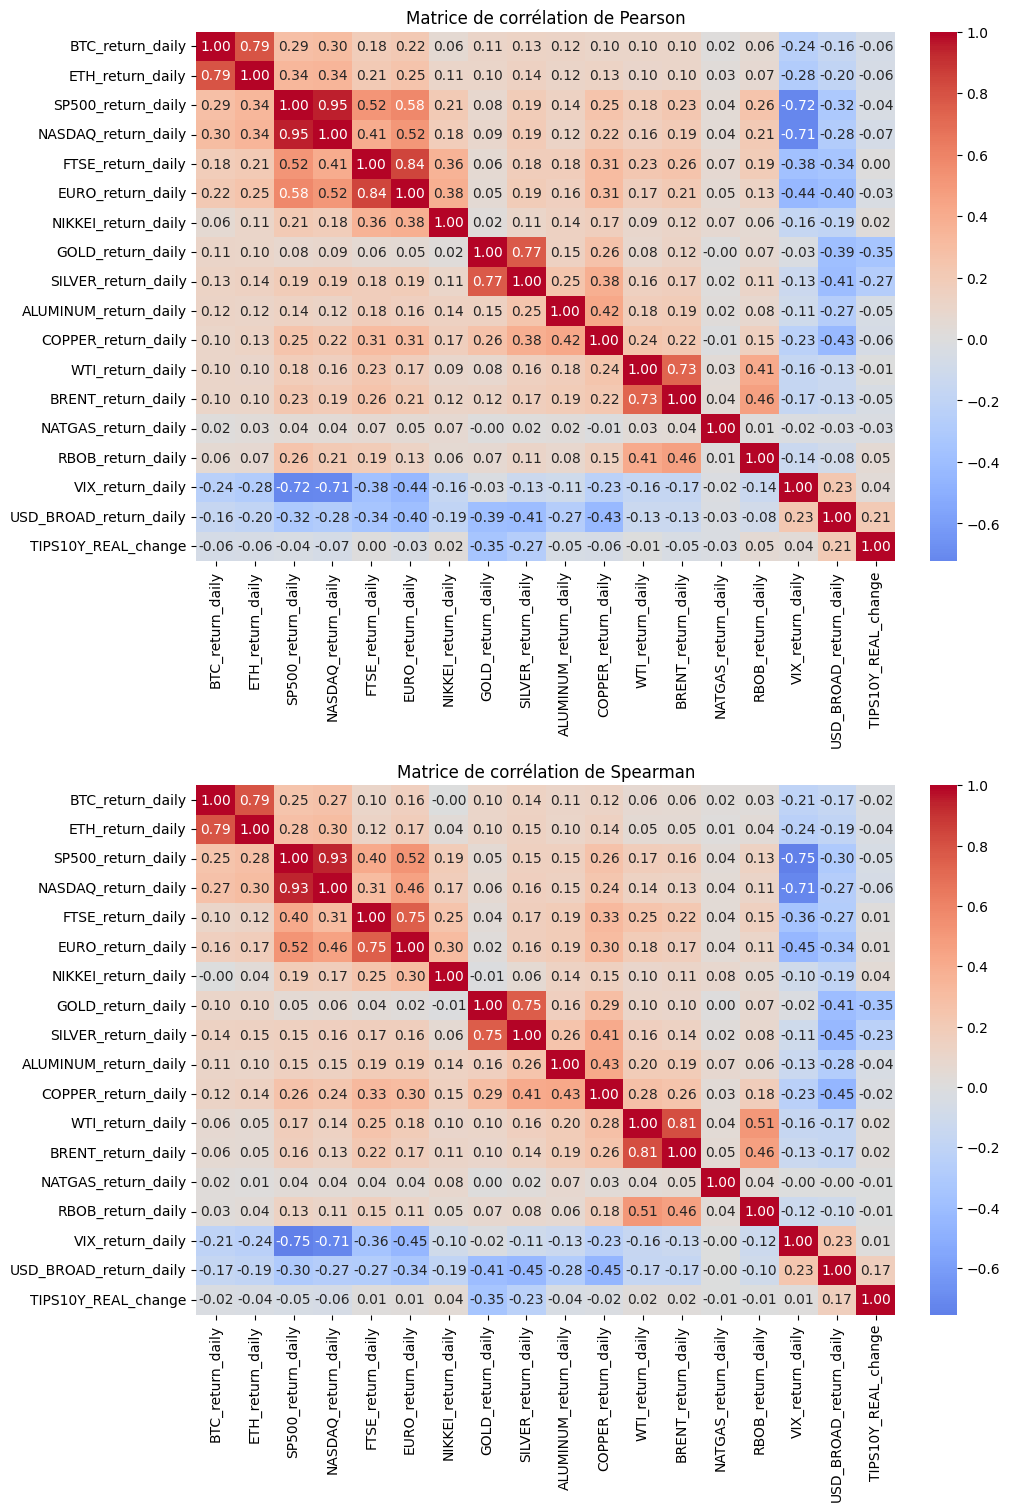

In [5]:
#-----Corrélations-----


# Préparer les données
return_cols = [c for c in df.columns if c.endswith('_return_daily')]
change_cols = [c for c in df.columns if c.endswith('_change')]

cols_corr = return_cols + change_cols
df_corr = df[cols_corr].dropna()

# Faires les matrices de corrélation: corrélation de Pearson et de Spearman
pearson = df_corr.corr(method='pearson')
spearman = df_corr.corr(method='spearman')

# Visualiser les matrices de corrrélation
fig, axes = plt.subplots(2, 1, figsize=(10, 15), constrained_layout=True)

sns.heatmap(pearson, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=axes[0])
axes[0].set_title("Matrice de corrélation de Pearson")

sns.heatmap(spearman, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=axes[1])
axes[1].set_title("Matrice de corrélation de Spearman")

plt.show()

Les valeurs des deux matrices sont proches. On note que les daily returns des cryptomonnaies sont très corrélés entre eux, une corrélation positive. De plus, les daily returns des cryptomonnaies sont peu corrélés avec les autres variables : les corrélations les plus élevées sont aves les marchés boursiers américains, des corrélations positives encore, mais elles sont relativement faibles.

Par ailleurs, on note la présence de nombreux blocs dans les matrices. Par exemple, la sous-matrice des indices boursiers forme un bloc de corrélations positives -- c’est moins vrai pour la bourse Nikkei. De même, l’or est positivement corrélé à l’argent, le cuivre l’est à l’aluminium (les deux sont utilisés dans l’industrie), et les pétroles sont corrélés à la gasoline.

On note que les bourses américaines sont négativement corrélées avec l'indice VIX, qui est un indice de la volatilité sur le marché américain. De plus, l’or et l’argent sont négativement corrélés avec les titres du Trésor protégés contre l’inflation, `TIPS10Y_REAL`, et avec la valeur du dolar -- à un moindre degré, cela est également vrai pour les bourses en dehors des États-Unis avec ces titres et avec le dolar. Dans tous les cas, on n’observe pas de forte corrélation avec les cryptomonnaies.

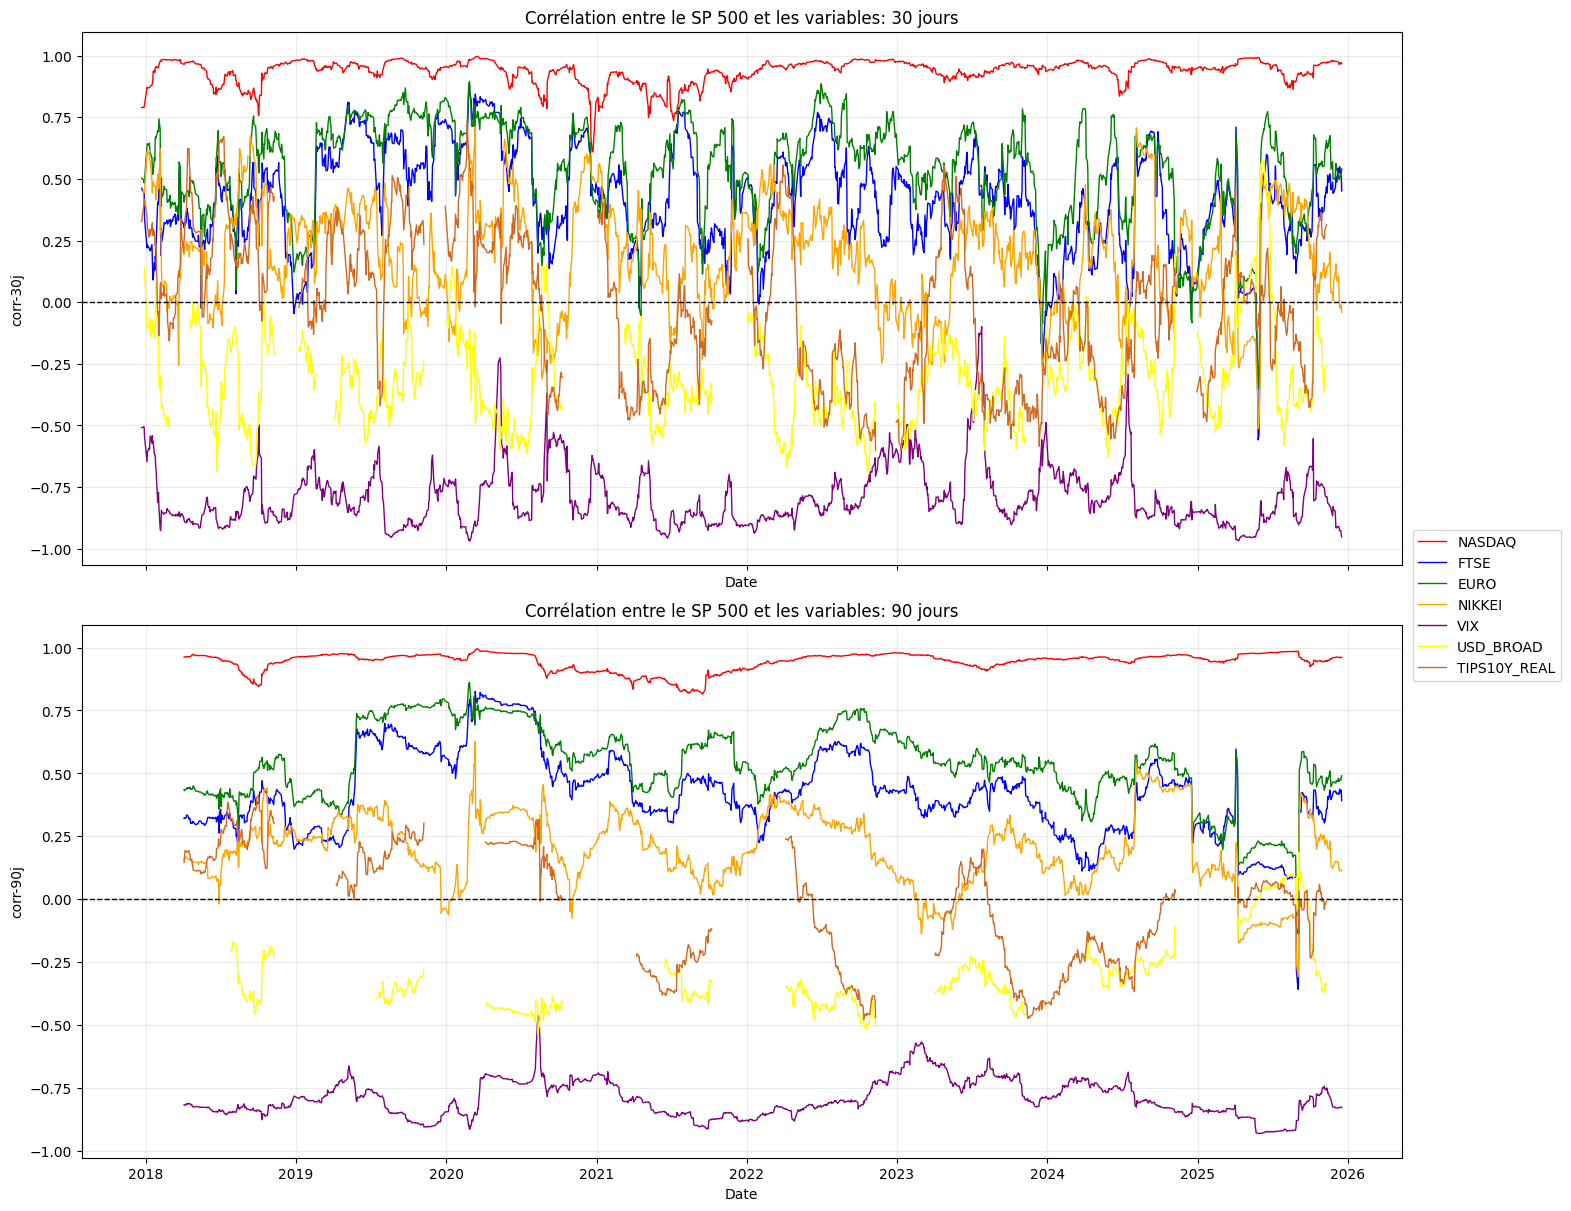

In [6]:
#-----Corrélations glissantes-----


# Sélectionner les variables et les fenêtres temporelles
sp500_pairs = ['NASDAQ_return_daily', 'FTSE_return_daily', 'EURO_return_daily', 'NIKKEI_return_daily', 'VIX_return_daily', 
               'USD_BROAD_return_daily', 'TIPS10Y_REAL_change']

windows = [30, 90]

# Préparer la visualisation
colors = {'NASDAQ_return_daily': 'red', 'FTSE_return_daily': 'blue', 'EURO_return_daily': 'green',
          'NIKKEI_return_daily': 'orange', 'VIX_return_daily': 'purple', 'USD_BROAD_return_daily': 'yellow',
          'TIPS10Y_REAL_change': 'chocolate'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for time in windows:

    aux_var = windows.index(time)

    # Calculer les corrélations glissantes
    rolling_corr_sp500 = pd.DataFrame({'timestamp': df['timestamp']})

    for col in sp500_pairs:

        rolling_corr_sp500[col] = df['SP500_return_daily'].rolling(time).corr(df[col])

    # Préparer la visualisation
    for col in sp500_pairs:
    
        axes[aux_var].plot(rolling_corr_sp500['timestamp'], rolling_corr_sp500[col], color=colors[col], linewidth=1,
            label=col.replace('_return_daily', '').replace('_change', ''))

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le SP 500 et les variables: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

.........................

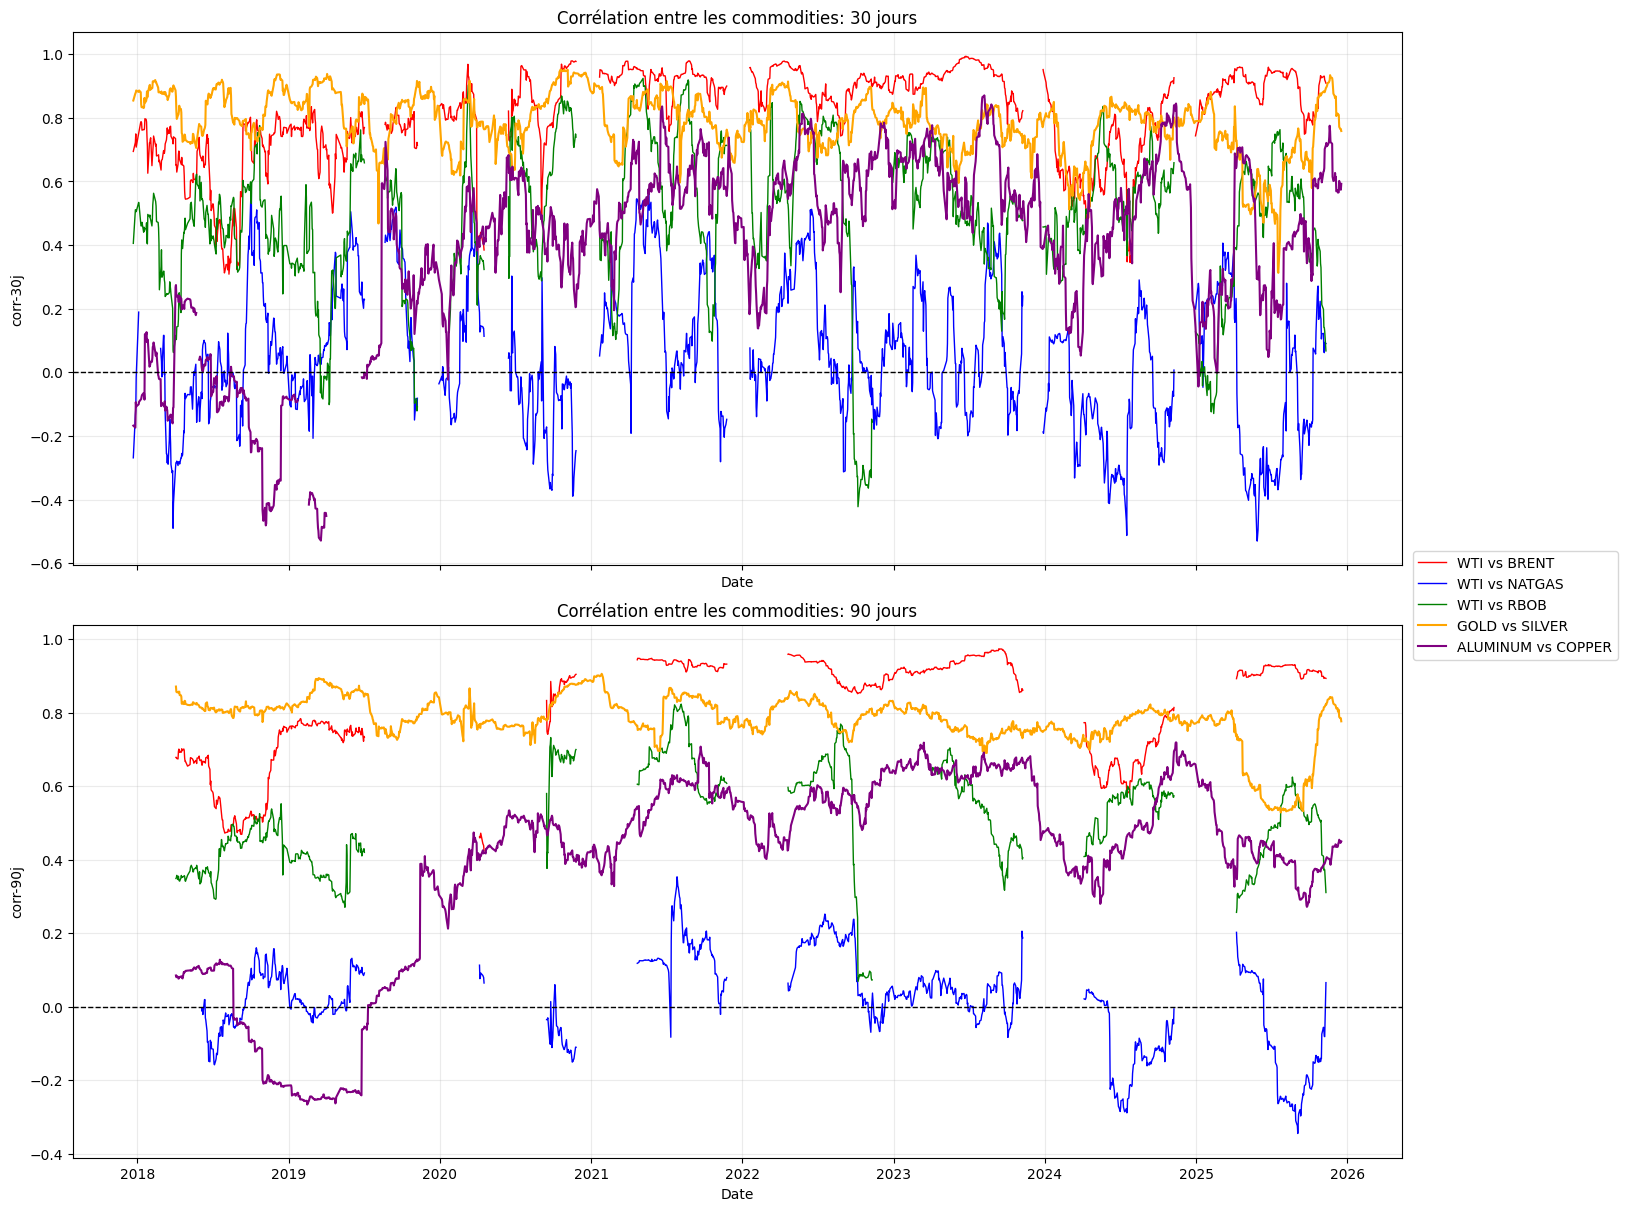

In [7]:
# Sélectionner les variables et les fenêtres temporelles
wti_pairs = ['BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily']

window = [30, 90]

# Préparer la visualisation
colors = {'BRENT_return_daily': 'red', 'NATGAS_return_daily': 'blue', 'RBOB_return_daily': 'green'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for time in window:

    aux_var = windows.index(time)

    # Calculer les corrélations glissantes
    rolling_corr_wti = pd.DataFrame({'timestamp': df['timestamp']})

    for col in wti_pairs:
        rolling_corr_wti[col] = df['WTI_return_daily'].rolling(time).corr(df[col])

    rolling_corr_gold = df['GOLD_return_daily'].rolling(time).corr(df['SILVER_return_daily'])
    rolling_corr_aluminium = df['ALUMINUM_return_daily'].rolling(time).corr(df['COPPER_return_daily'])

    # Préparer la visualisation
    for col in wti_pairs:
        axes[aux_var].plot(rolling_corr_wti['timestamp'], rolling_corr_wti[col], color=colors[col], linewidth=1, 
                           label=f'WTI vs {col.replace('_return_daily', '')}')

    axes[aux_var].plot(df['timestamp'], rolling_corr_gold, label='GOLD vs SILVER', color='orange')
    axes[aux_var].plot(df['timestamp'], rolling_corr_aluminium, label='ALUMINUM vs COPPER', color='purple')

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre les commodities: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

.....

In [10]:
time = 90

# Préparer les corrélations glissantes
btc_pairs = ['ETH_return_daily', 'SP500_return_daily', 'NASDAQ_return_daily', 'FTSE_return_daily', 
             'EURO_return_daily', 'NIKKEI_return_daily', 'GOLD_return_daily', 'SILVER_return_daily', 'ALUMINUM_return_daily', 
             'COPPER_return_daily', 'WTI_return_daily', 'BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily', 
             'VIX_return_daily', 'USD_BROAD_return_daily','TIPS10Y_REAL_change']

eth_pairs = ['BTC_return_daily', 'SP500_return_daily', 'NASDAQ_return_daily', 'FTSE_return_daily', 
             'EURO_return_daily', 'NIKKEI_return_daily', 'GOLD_return_daily', 'SILVER_return_daily', 'ALUMINUM_return_daily', 
             'COPPER_return_daily', 'WTI_return_daily', 'BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily', 
             'VIX_return_daily', 'USD_BROAD_return_daily','TIPS10Y_REAL_change']

btc_rolling = pd.DataFrame({'timestamp': df['timestamp']})
eth_rolling = pd.DataFrame({'timestamp': df['timestamp']})

for col in btc_pairs:
    tmp_var = df[['BTC_return_daily', col]].dropna()
    btc_rolling[col] = tmp_var['BTC_return_daily'].rolling(time).corr(tmp_var[col])

for col in eth_pairs:
    tmp_var = df[['ETH_return_daily', col]].dropna()
    eth_rolling[col] = tmp_var['ETH_return_daily'].rolling(time).corr(tmp_var[col])

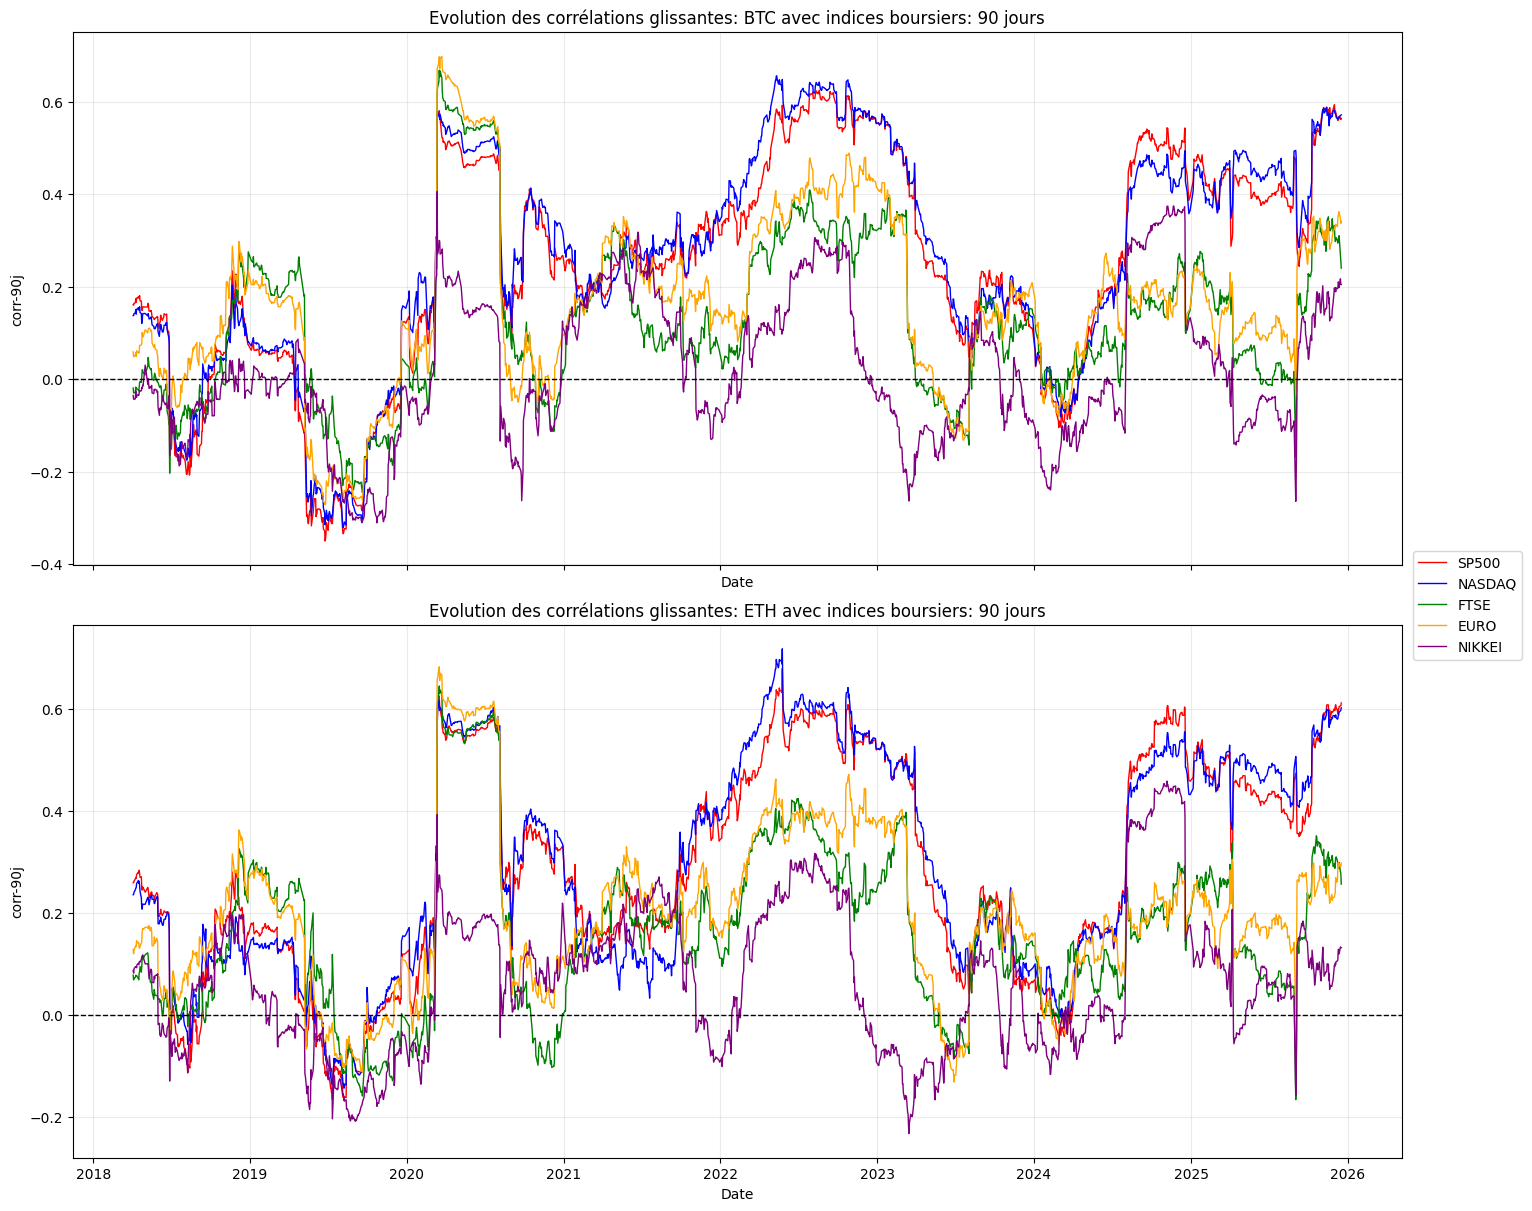

In [11]:
# Sélectionner les variables
stock_markets = ['SP500_return_daily', 'NASDAQ_return_daily', 'FTSE_return_daily', 'EURO_return_daily', 'NIKKEI_return_daily']

# Préparer la visualisation
colors = {'SP500_return_daily': 'red', 'NASDAQ_return_daily': 'blue', 'FTSE_return_daily': 'green', 'EURO_return_daily': 'orange', 
          'NIKKEI_return_daily': 'purple'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in stock_markets:
    
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1,  label=col.replace('_return_daily', ''))

for name in ['BTC', 'ETH']:

    aux_var = ['BTC', 'ETH'].index(name)

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le {name} et les indices boursiers: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

.....................

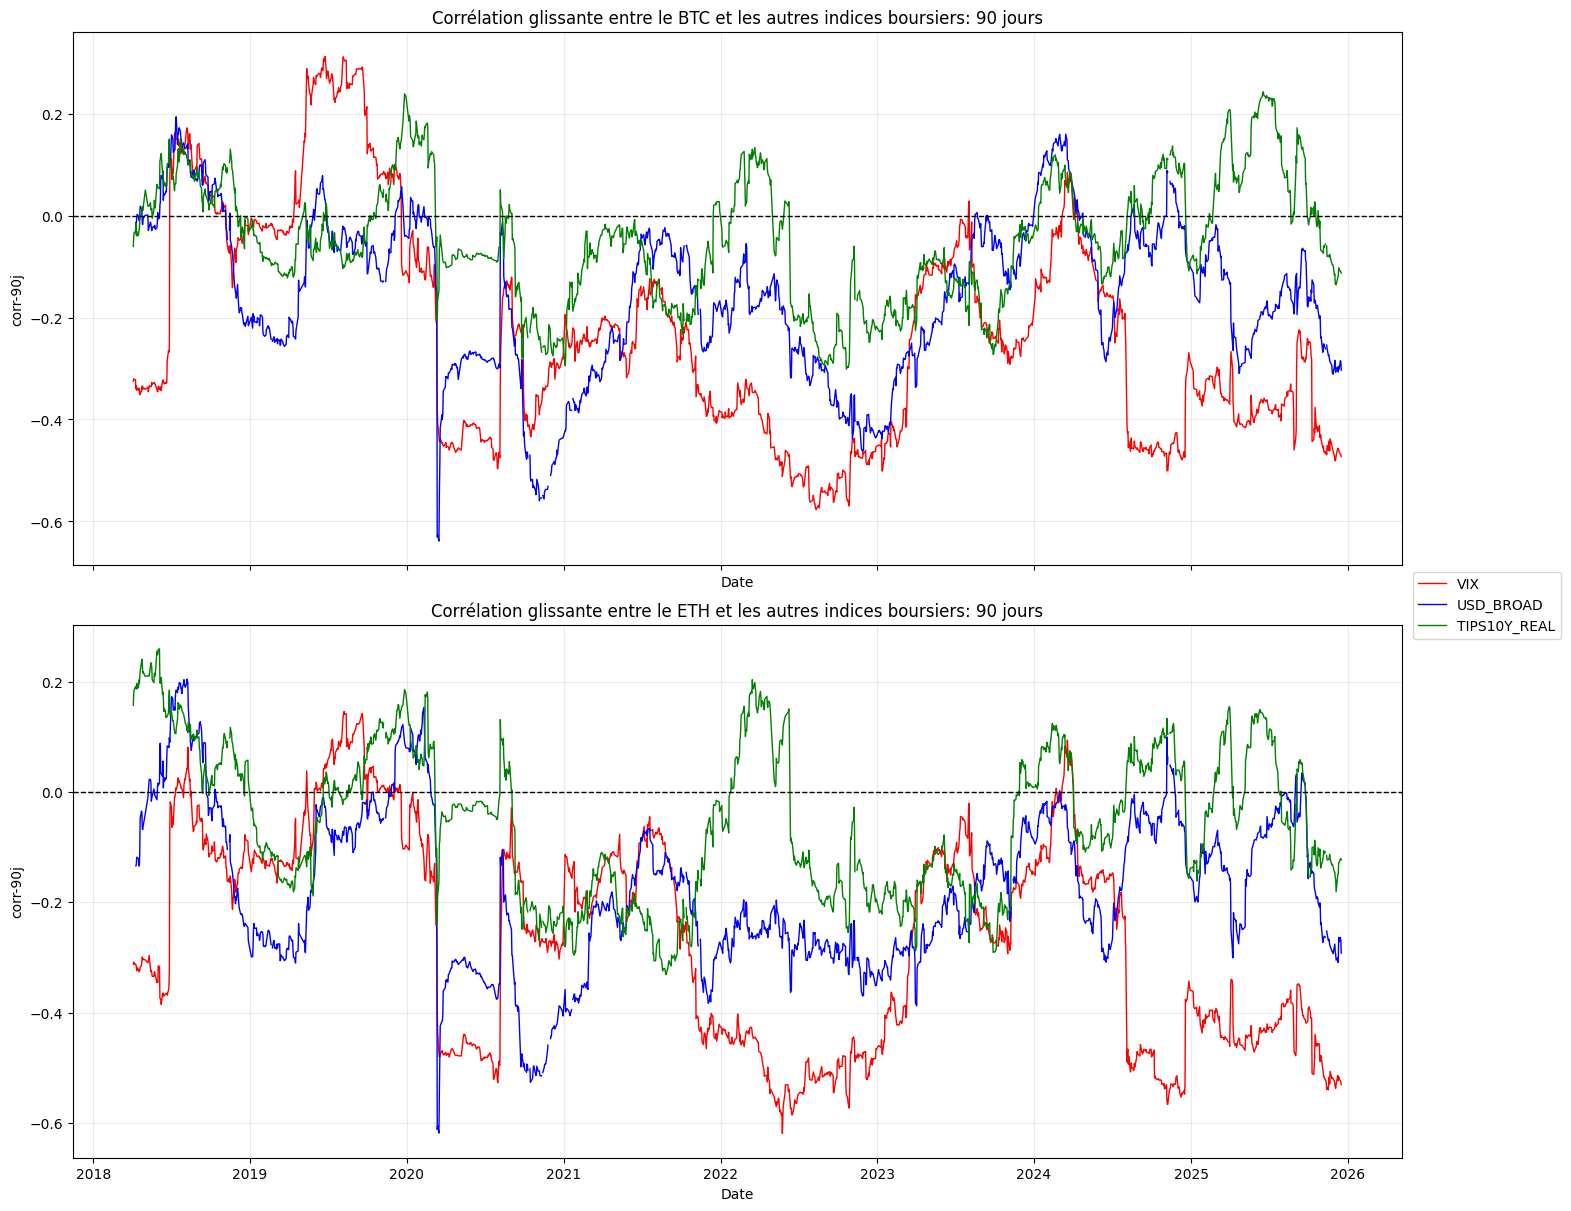

In [13]:
# Sélectionner les variables
indices = ['VIX_return_daily', 'USD_BROAD_return_daily', 'TIPS10Y_REAL_change']

# Préparer la visualisation
colors = {'VIX_return_daily': 'red', 'USD_BROAD_return_daily': 'blue', 'TIPS10Y_REAL_change': 'green'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in indices:
    
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', '').replace('_change', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', '').replace('_change', ''))
    
for name in ['BTC', 'ETH']:

    aux_var = ['BTC', 'ETH'].index(name)

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le {name} et les autres indices boursiers: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

..............

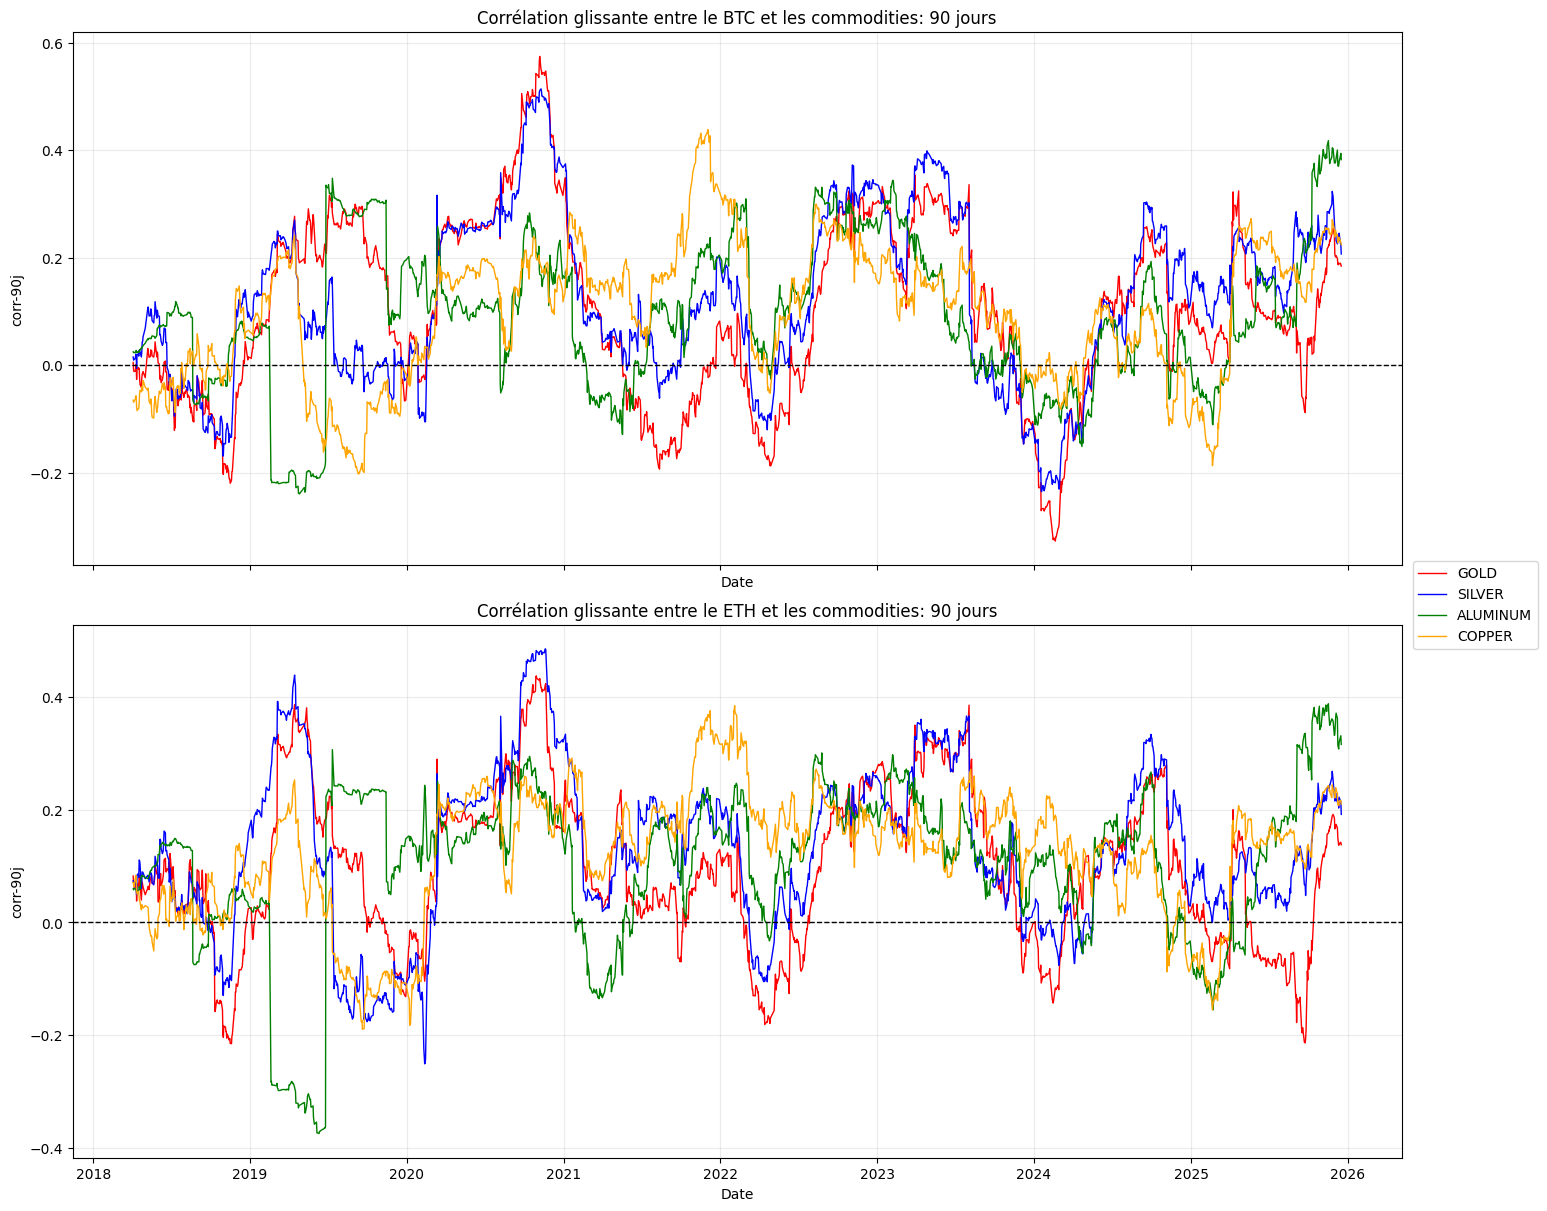

In [14]:
# Sélectionner les variables
commodities = ['GOLD_return_daily', 'SILVER_return_daily', 'ALUMINUM_return_daily', 'COPPER_return_daily']

# Préparer la visualisation
colors = {'GOLD_return_daily': 'red', 'SILVER_return_daily': 'blue', 'ALUMINUM_return_daily': 'green', 'COPPER_return_daily': 'orange'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in commodities:
    
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))

for name in ['BTC', 'ETH']:

    aux_var = ['BTC', 'ETH'].index(name)

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le {name} et les commodities: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

.......................

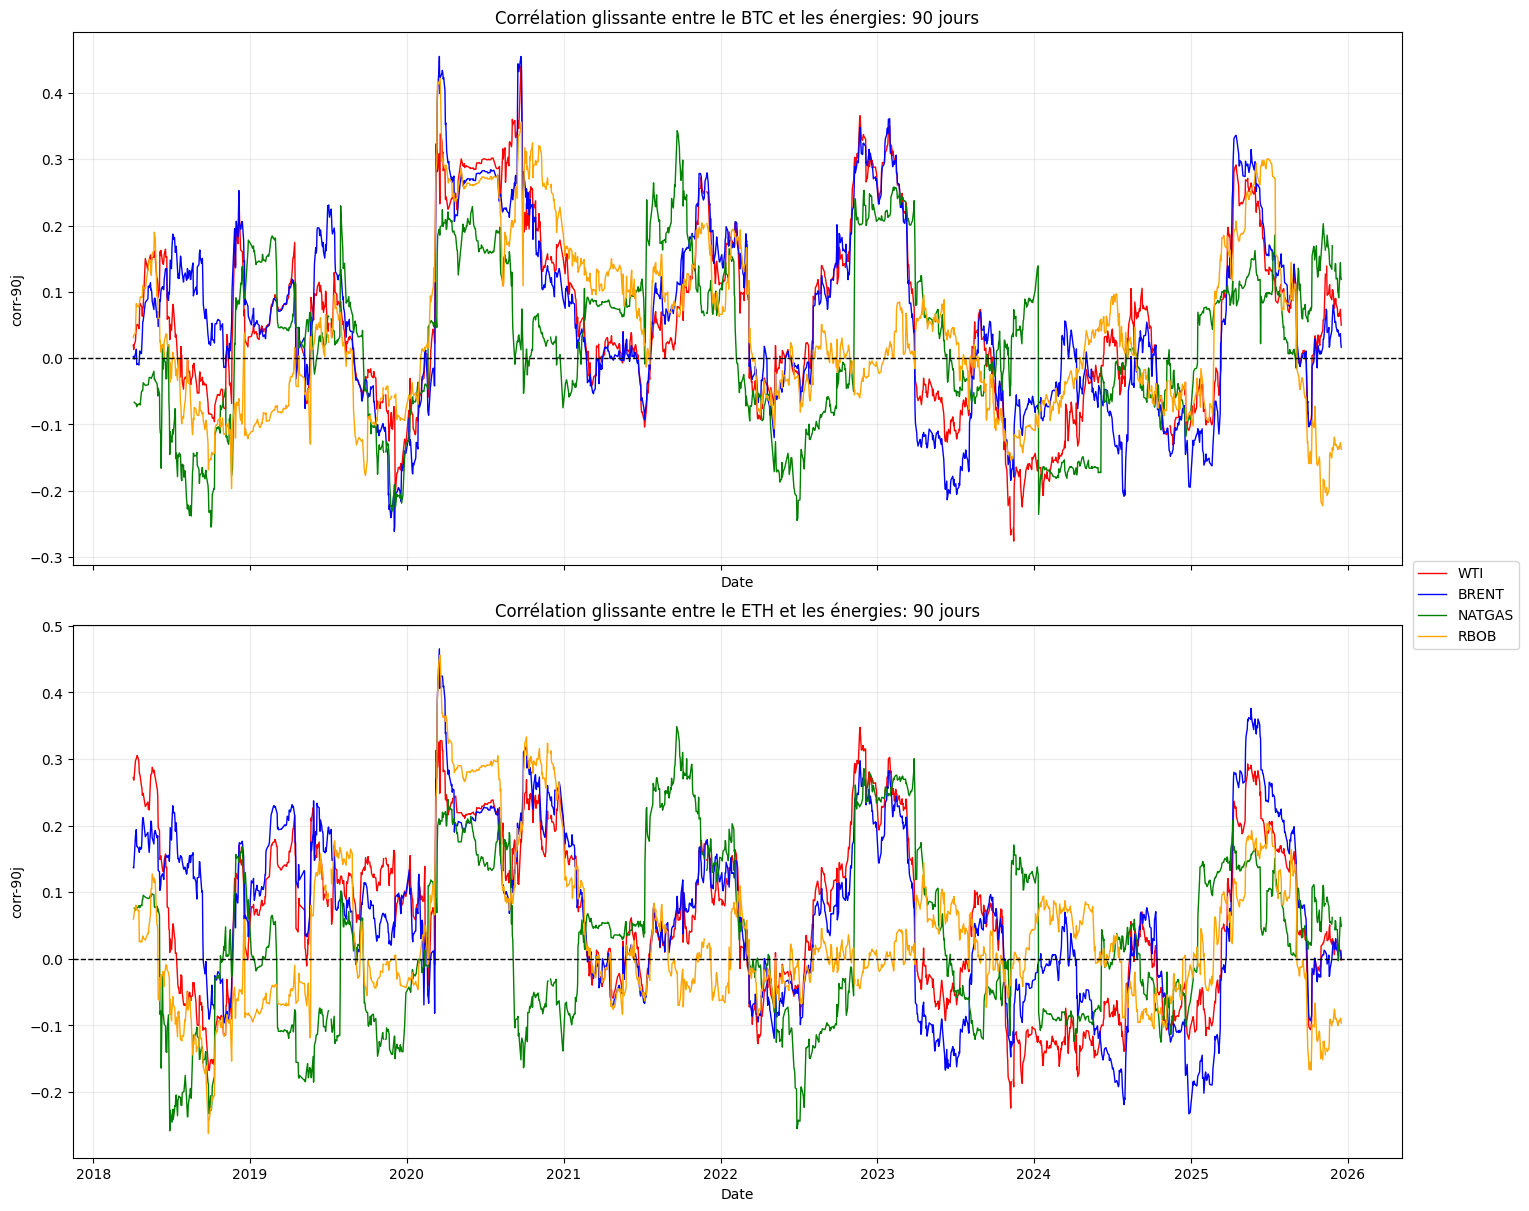

In [15]:
# Sélectionner les variables
energy_markets = ['WTI_return_daily', 'BRENT_return_daily', 'NATGAS_return_daily', 'RBOB_return_daily']

# Préparer la visualisation
colors = {'WTI_return_daily': 'red', 'BRENT_return_daily': 'blue', 'NATGAS_return_daily': 'green', 'RBOB_return_daily': 'orange'}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in energy_markets:
    
    axes[0].plot(btc_rolling['timestamp'], btc_rolling[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))
    axes[1].plot(eth_rolling['timestamp'], eth_rolling[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))
    
for name in ['BTC', 'ETH']:

    aux_var = ['BTC', 'ETH'].index(name)

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le {name} et les énergies: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

...................

<Figure size 1400x700 with 0 Axes>

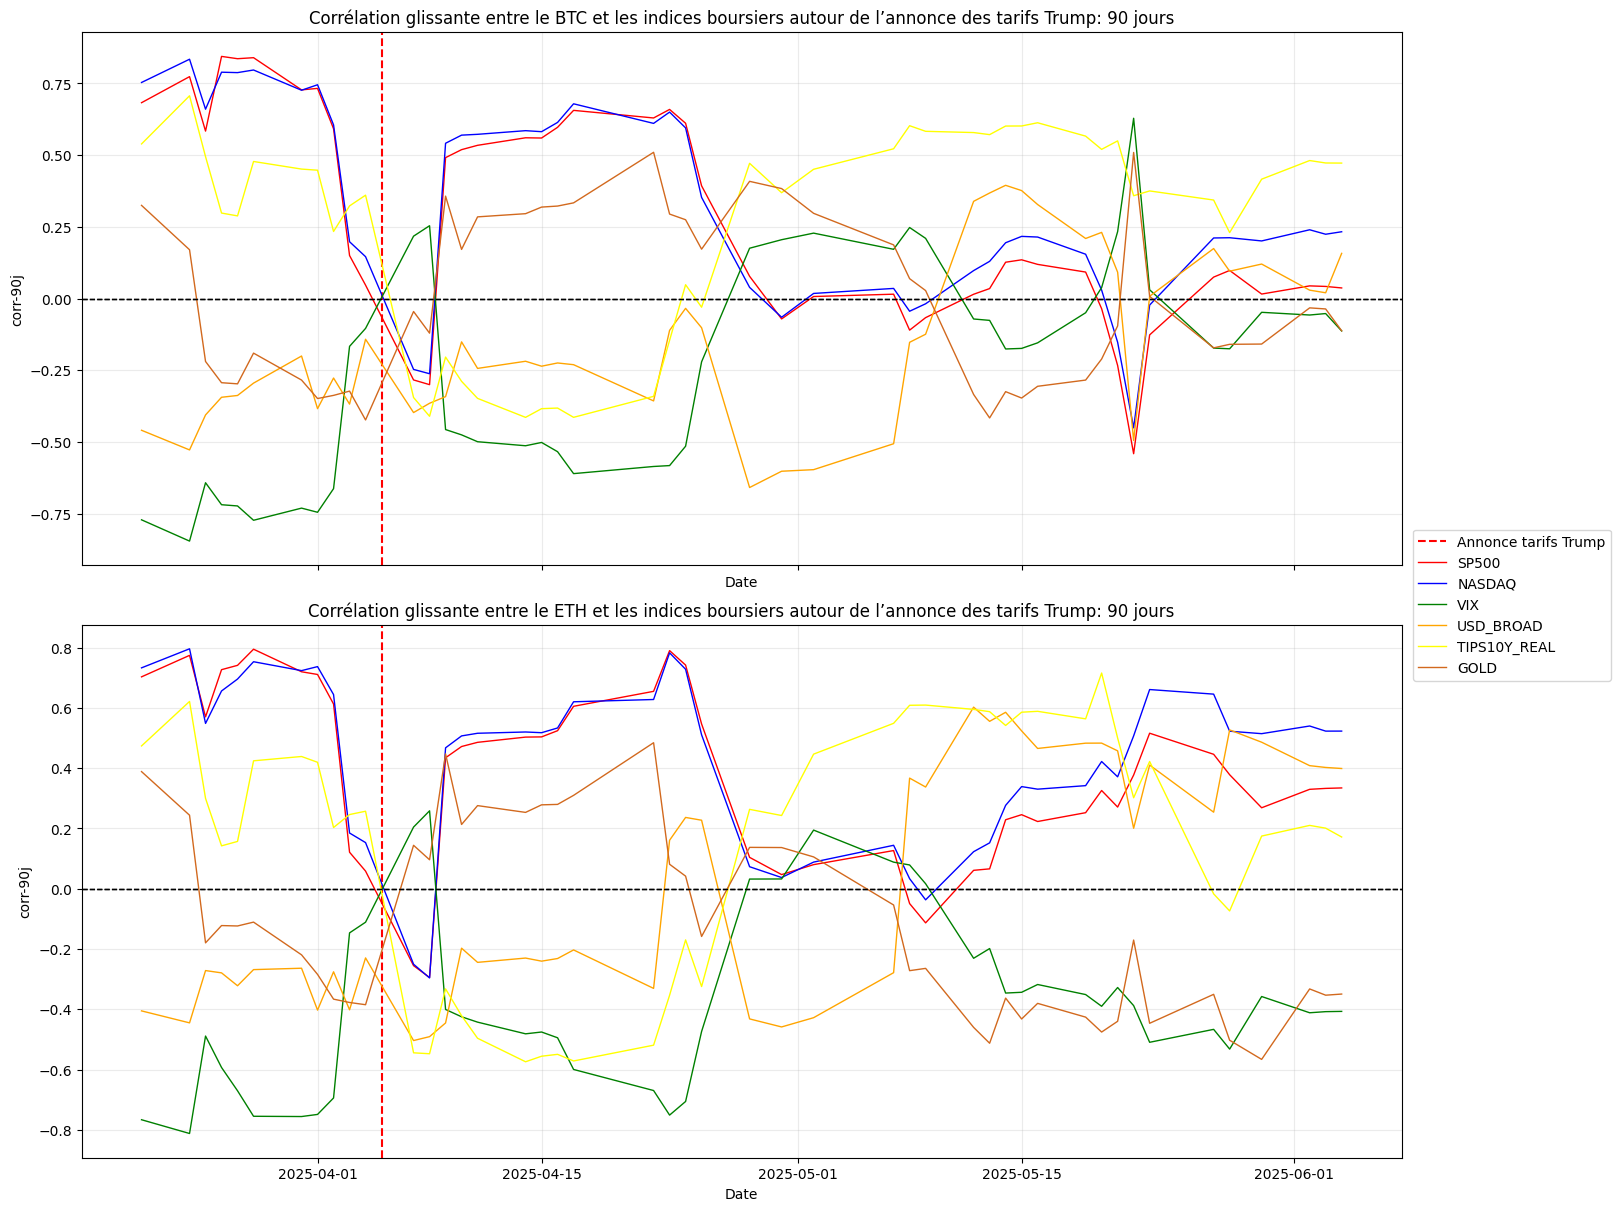

In [18]:
# Date de l'événement macroéconomique
event_date = pd.to_datetime("2025-04-05")

# Fenêtre autour de l'événement (-15 jours avant l'événement et 30 jours après)
start_date = event_date - pd.Timedelta(days=15)
end_date = event_date + pd.Timedelta(days=60)

# Sous-échantillon autour de l'événement
event_df = df[(df["timestamp"] >= start_date) & (df["timestamp"] <= end_date)].copy()

# Taille de la corrélation glissante (court terme)
rolling_window = 10

indices = ['SP500_return_daily', 'NASDAQ_return_daily', 'VIX_return_daily', 'USD_BROAD_return_daily', 'TIPS10Y_REAL_change', 'GOLD_return_daily']

colors = {'SP500_return_daily': 'red', 'NASDAQ_return_daily': 'blue', 'VIX_return_daily': 'green', 'USD_BROAD_return_daily' : 'orange', 
          'TIPS10Y_REAL_change' : 'yellow', 'GOLD_return_daily': 'chocolate'}

btc_trump_rolling_corr = pd.DataFrame({'timestamp': event_df['timestamp']})
eth_trump_rolling_corr = pd.DataFrame({'timestamp': event_df['timestamp']})

for col in indices:
    btc_trump_rolling_corr[col] = df['BTC_return_daily'].rolling(rolling_window).corr(df[col])
    eth_trump_rolling_corr[col] = df['ETH_return_daily'].rolling(rolling_window).corr(df[col])

plt.figure(figsize=(14, 7))

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

# Références graphiques
for i in [0, 1]:
    axes[i].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[i].axvline(event_date, color="red", linestyle="--", label="Annonce tarifs Trump")

for col in indices:
    axes[0].plot(btc_trump_rolling_corr['timestamp'], btc_trump_rolling_corr[col], color=colors[col], linewidth=1,
        label=col.replace('_return_daily', '').replace('_change', ''))
    axes[1].plot(eth_trump_rolling_corr['timestamp'], eth_trump_rolling_corr[col], color=colors[col], linewidth=1, 
        label=col.replace('_return_daily', '').replace('_change', ''))

for name in ['BTC', 'ETH']:

    aux_var = ['BTC', 'ETH'].index(name)

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le {name} et les indices boursiers autour de l’annonce des tarifs Trump: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

<Figure size 1400x700 with 0 Axes>

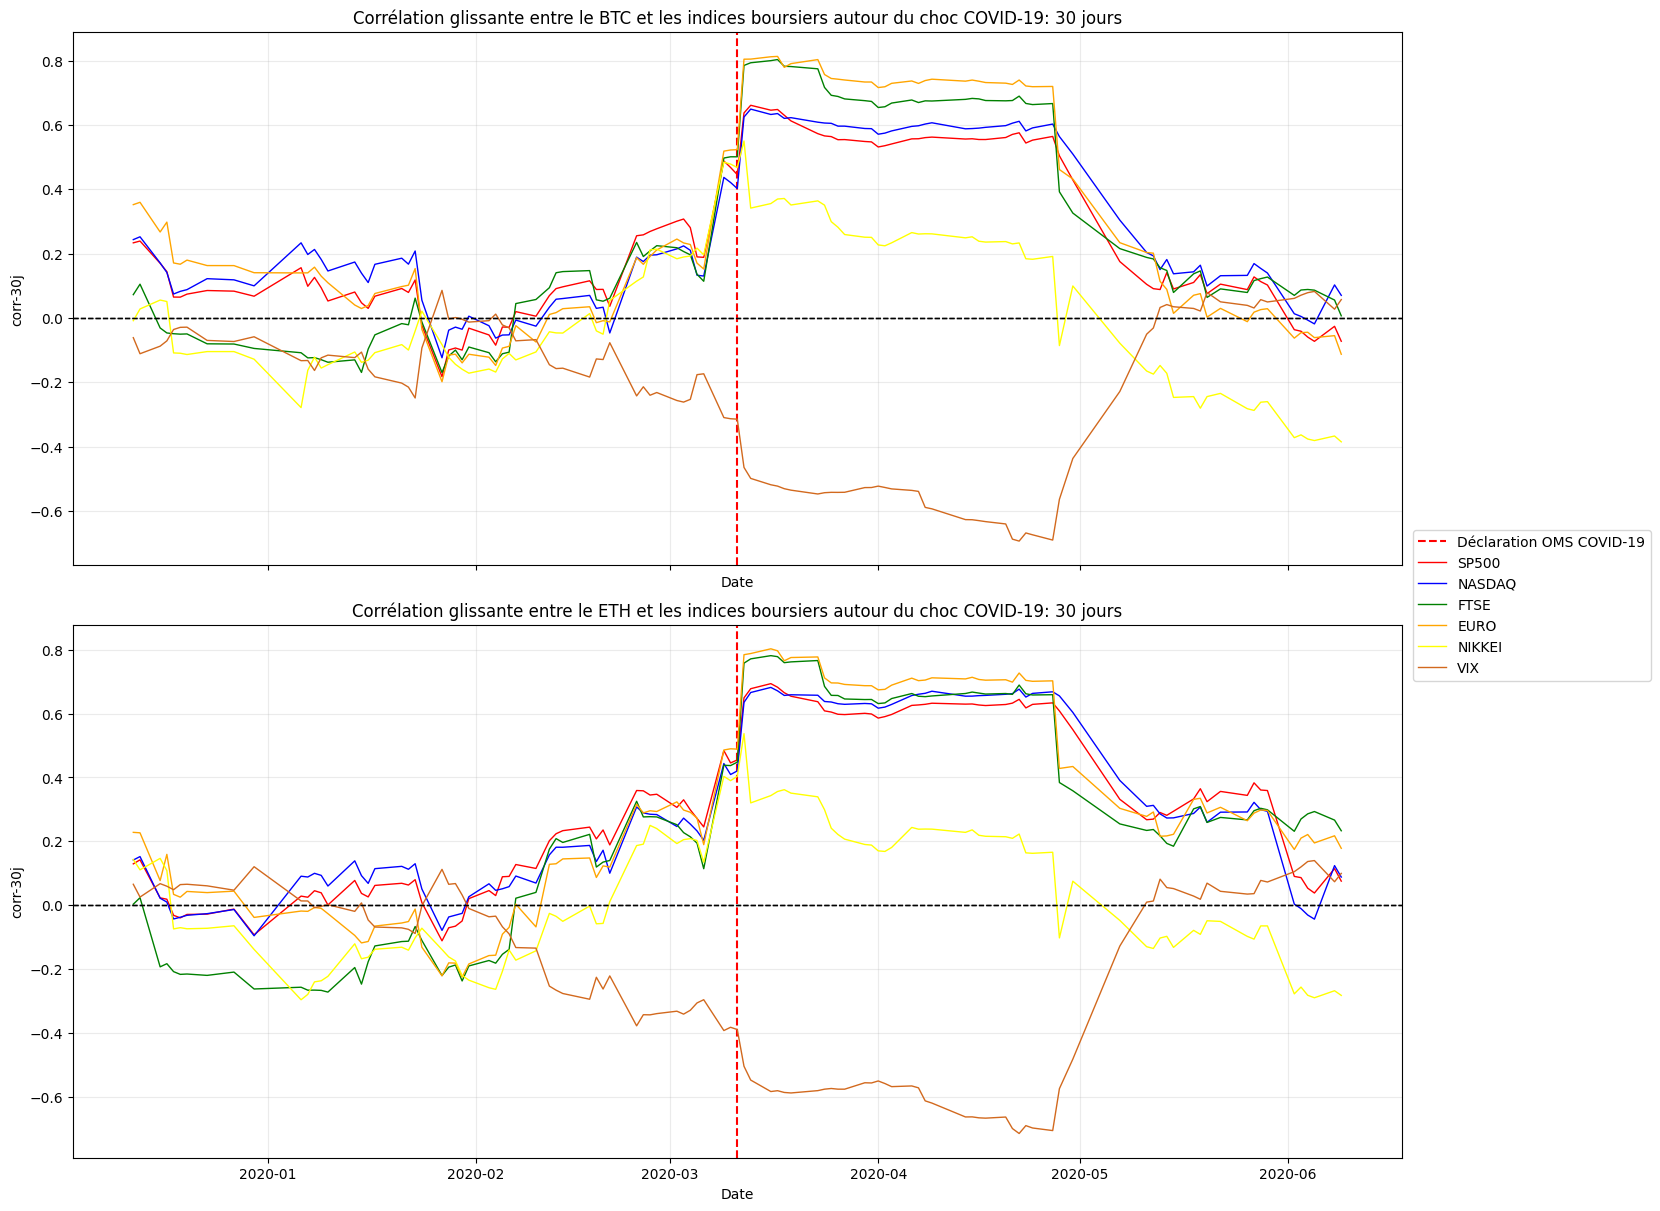

In [19]:
# Date de l'annonce majeure du COVID-19
event_date = pd.to_datetime('2020-03-11')

# On analyse la période -90 jours avant et 90 après l’événement
start_date = event_date - pd.Timedelta(days=90)
end_date = event_date + pd.Timedelta(days=90)

# Filtrer le dataset
event_df = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

#
time = 30

# Liste des indices pour calcul de corrélation avec cryptos
indices_stocks = ["SP500_return_daily", "NASDAQ_return_daily", "FTSE_return_daily", "EURO_return_daily", "NIKKEI_return_daily", "VIX_return_daily"]

indices = ['GOLD_return_daily', 'ALUMINUM_return_daily', 'WTI_return_daily', 'USD_BROAD_return_daily', 'TIPS10Y_REAL_change']

colors = {'SP500_return_daily': 'red', 'NASDAQ_return_daily': 'blue', 'FTSE_return_daily': 'green', 'EURO_return_daily': 'orange', 
          'NIKKEI_return_daily' : 'yellow', 'VIX_return_daily': 'chocolate', 'GOLD_return_daily': 'red', 'ALUMINUM_return_daily': 'blue', 
          'WTI_return_daily': 'green', 'USD_BROAD_return_daily': 'orange', 'TIPS10Y_REAL_change': 'yellow'}

# Calcul des corrélations glissantes (rolling 30 jours)

btc_covid_rolling_corr_stocks = pd.DataFrame({'timestamp': event_df['timestamp']})
eth_covid_rolling_corr_stocks = pd.DataFrame({'timestamp': event_df['timestamp']})
btc_covid_rolling_corr_indices = pd.DataFrame({'timestamp': event_df['timestamp']})
eth_covid_rolling_corr_indices = pd.DataFrame({'timestamp': event_df['timestamp']})

for col in indices_stocks:
    btc_covid_rolling_corr_stocks[col] = df['BTC_return_daily'].rolling(time).corr(df[col])
    eth_covid_rolling_corr_stocks[col] = df['ETH_return_daily'].rolling(time).corr(df[col])
    
for col in indices:
    btc_covid_rolling_corr_indices[col] = df['BTC_return_daily'].rolling(time).corr(df[col])
    eth_covid_rolling_corr_indices[col] = df['ETH_return_daily'].rolling(time).corr(df[col])

# Visualisation

plt.figure(figsize=(14, 7))

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

# Références graphiques
for i in [0, 1]:
    axes[i].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[i].axvline(event_date, color="red", linestyle="--", label="Déclaration OMS COVID-19")

for col in indices_stocks:
    axes[0].plot(btc_covid_rolling_corr_stocks['timestamp'], btc_covid_rolling_corr_stocks[col], color=colors[col], 
                 linewidth=1, label=col.replace('_return_daily', ''))
    axes[1].plot(eth_covid_rolling_corr_stocks['timestamp'], eth_covid_rolling_corr_stocks[col], color=colors[col], 
                 linewidth=1, label=col.replace('_return_daily', ''))

for name in ['BTC', 'ETH']:

    aux_var = ['BTC', 'ETH'].index(name)

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le {name} et les indices boursiers autour du choc COVID-19: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

.........

<Figure size 1400x700 with 0 Axes>

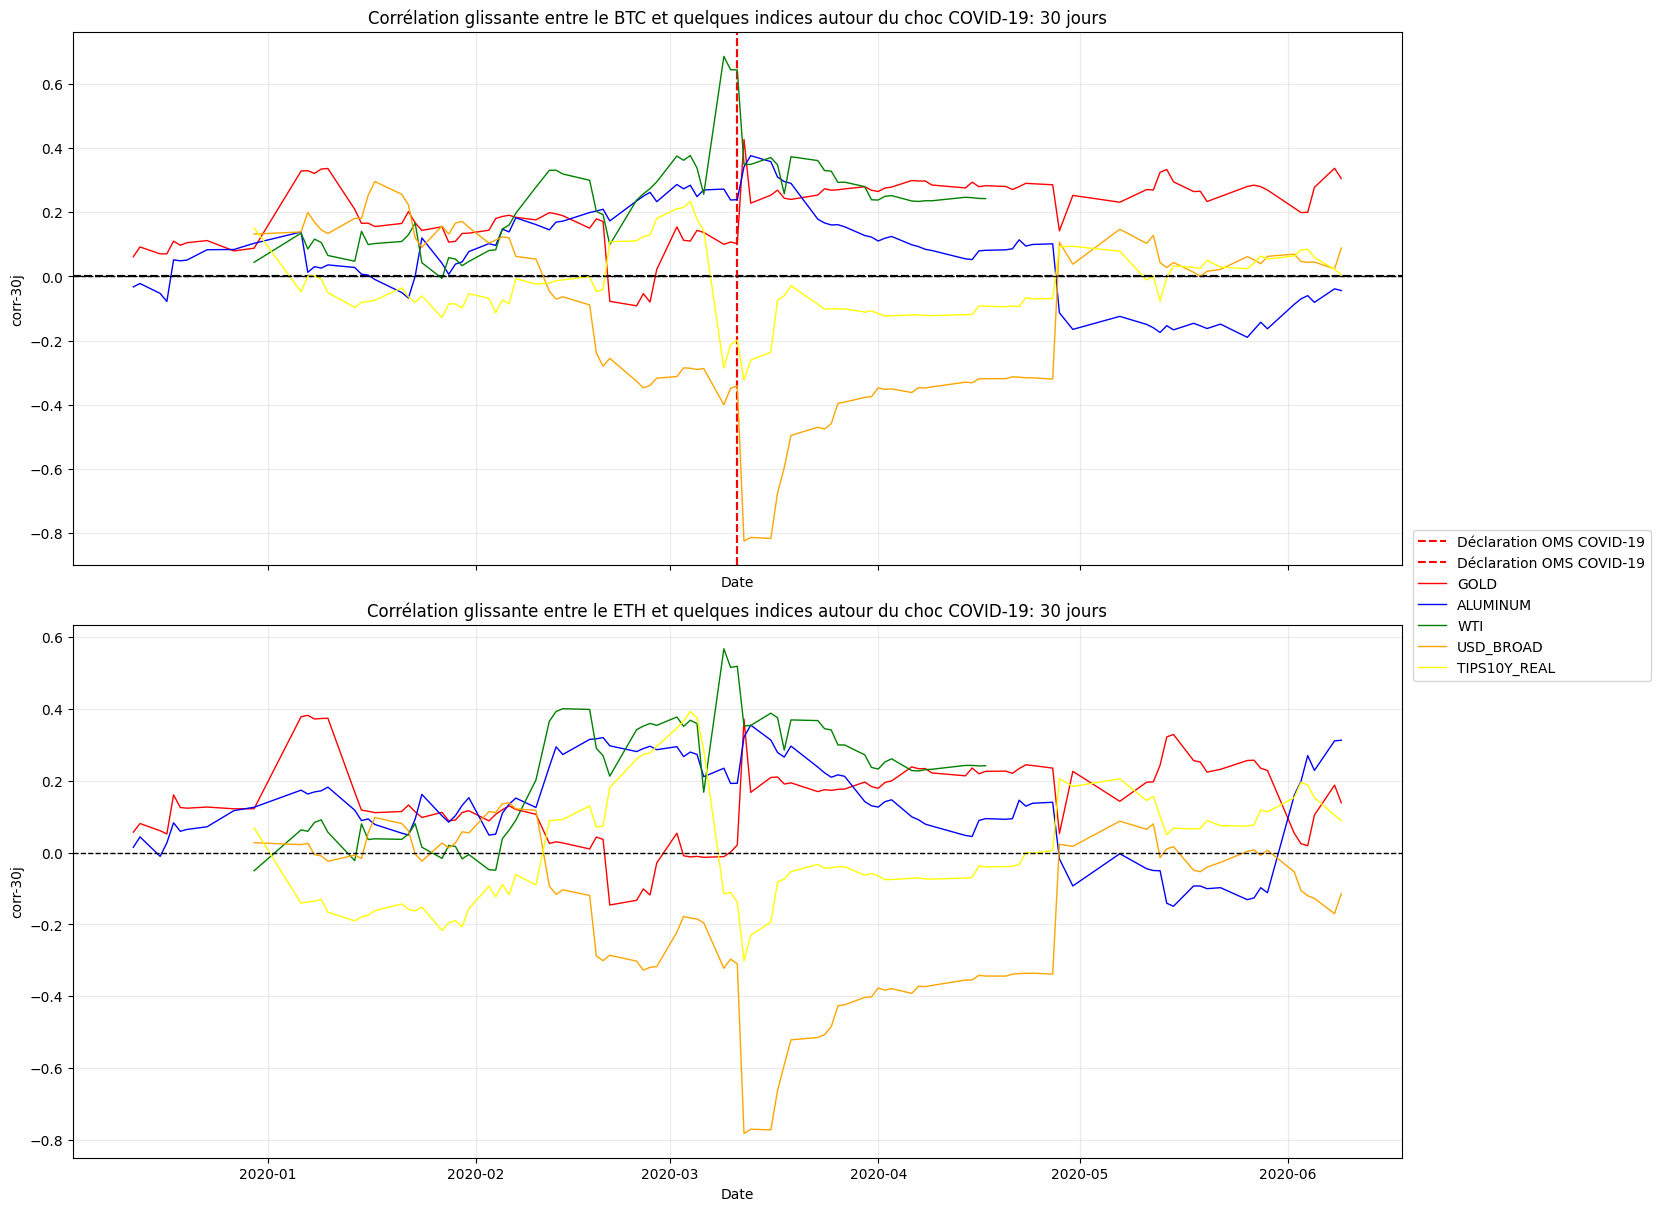

In [20]:
plt.figure(figsize=(14, 7))

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

# Références graphiques
for i in [0, 1]:
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].axvline(event_date, color='red', linestyle='--', label='Déclaration OMS COVID-19')

for col in indices:
    axes[0].plot(btc_covid_rolling_corr_indices['timestamp'], btc_covid_rolling_corr_indices[col], color=colors[col], linewidth=1,
                 label=col.replace('_return_daily', '').replace('_change', ''))
    axes[1].plot(eth_covid_rolling_corr_indices['timestamp'], eth_covid_rolling_corr_indices[col], color=colors[col], linewidth=1,
                 label=col.replace('_return_daily', '').replace('_change', ''))

for name in ['BTC', 'ETH']:

    aux_var = ['BTC', 'ETH'].index(name)

    axes[aux_var].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[aux_var].set_xlabel('Date')
    axes[aux_var].set_ylabel(f'corr-{time}j')
    axes[aux_var].set_title(f'Corrélation glissante entre le {name} et quelques indices autour du choc COVID-19: {time} jours')
    axes[aux_var].grid(True, alpha=0.25)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

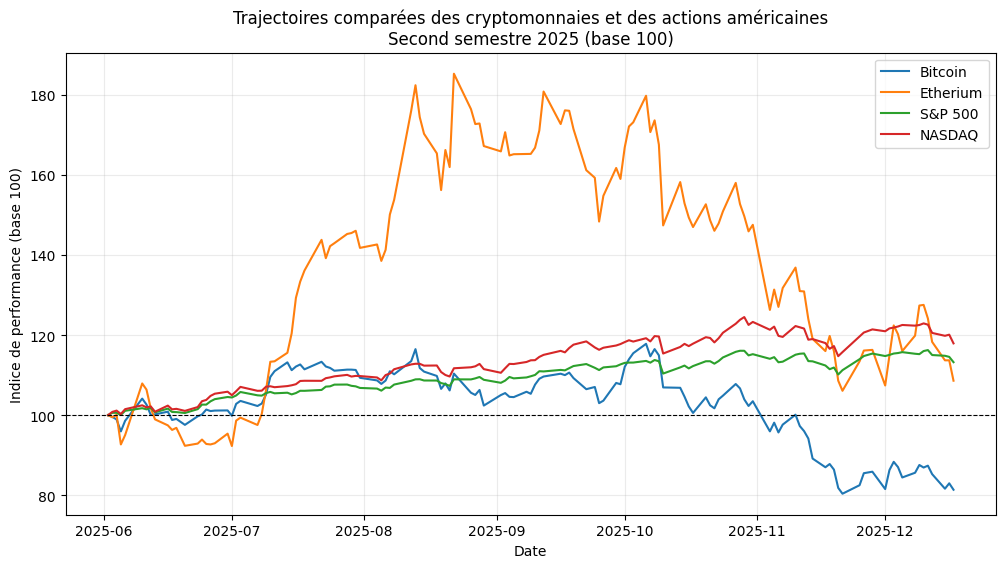

In [16]:
# Définir la période : second semestre 2025
start_date = pd.to_datetime("2025-06-01")
end_date = pd.to_datetime("2025-12-23")

df_2025 = df[(df["timestamp"] >= start_date) & (df["timestamp"] <= end_date)].copy()

# Calcul des performances cumulées (base 100)
assets = {"Bitcoin": "BTC_price", "Etherium": "ETH_price", "S&P 500": "SP500_price", "NASDAQ": "NASDAQ_price"}

for name, col in assets.items():
    df_2025[name] = 100 * df_2025[col] / df_2025[col].iloc[0]

# Graphique
plt.figure(figsize=(12,6))

for name in assets.keys():
    plt.plot(df_2025["timestamp"], df_2025[name], label=name)

plt.axhline(100, color="black", linestyle="--", linewidth=0.8)
plt.title("Trajectoires comparées des cryptomonnaies et des actions américaines\nSecond semestre 2025 (base 100)")
plt.xlabel("Date")
plt.ylabel("Indice de performance (base 100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

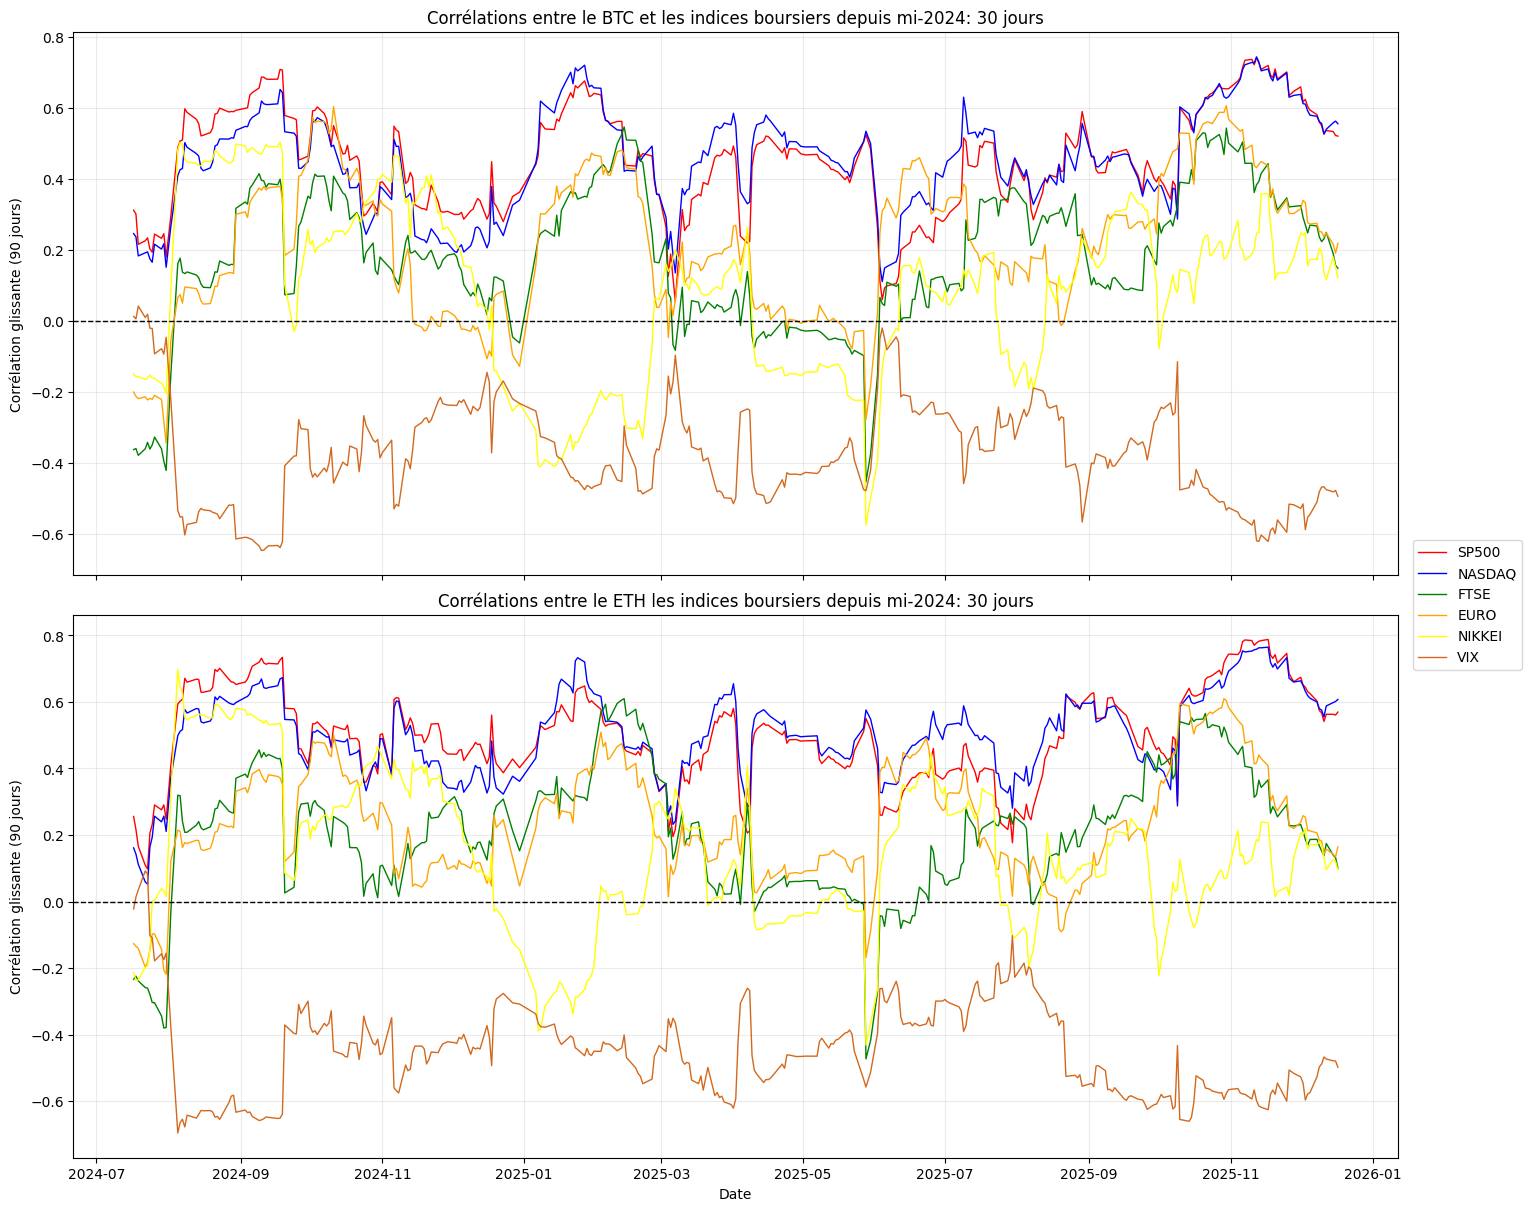

In [24]:
# Définir le début de la période (mi-2024)
start_date = pd.to_datetime('2024-06-01')

time = 30

df_recent = (df.loc[df['timestamp'] >= start_date, ['timestamp', 'BTC_return_daily', 'ETH_return_daily', 
             'SP500_return_daily', 'NASDAQ_return_daily', 'FTSE_return_daily', 'EURO_return_daily', 'NIKKEI_return_daily', 
             'VIX_return_daily']].copy().reset_index(drop=True))

indices = ["SP500_return_daily", "NASDAQ_return_daily", "FTSE_return_daily", "EURO_return_daily", "NIKKEI_return_daily", "VIX_return_daily"]

colors = {'SP500_return_daily': 'red', 'NASDAQ_return_daily': 'blue', 'FTSE_return_daily': 'green',  'EURO_return_daily': 'orange',
          'NIKKEI_return_daily' : 'yellow', 'VIX_return_daily': 'chocolate', 'GOLD_return_daily': 'red', 'ALUMINUM_return_daily': 'blue',
          'WTI_return_daily': 'green', 'USD_BROAD_return_daily': 'orange', 'TIPS10Y_REAL_change': 'yellow'}

btc_2024_rolling_corr = pd.DataFrame({'timestamp': df_recent['timestamp']})
eth_2024_rolling_corr = pd.DataFrame({'timestamp': df_recent['timestamp']})

for col in indices:
    btc_2024_rolling_corr[col] = df_recent['BTC_return_daily'].rolling(time).corr(df_recent[col]).to_numpy()
    eth_2024_rolling_corr[col] = df_recent['ETH_return_daily'].rolling(time).corr(df_recent[col]).to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in indices:
    axes[0].plot(btc_2024_rolling_corr['timestamp'], btc_2024_rolling_corr[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))
    axes[1].plot(eth_2024_rolling_corr['timestamp'], eth_2024_rolling_corr[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))

for ax in axes:
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel(f'corr-{time}j')
    ax.grid(True, alpha=0.25)

axes[0].set_title(f'Corrélations entre le BTC et les indices boursiers depuis mi-2024: {time} jours')
axes[1].set_title(f'Corrélations entre le ETH les indices boursiers depuis mi-2024: {time} jours')
axes[1].set_xlabel('Date')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

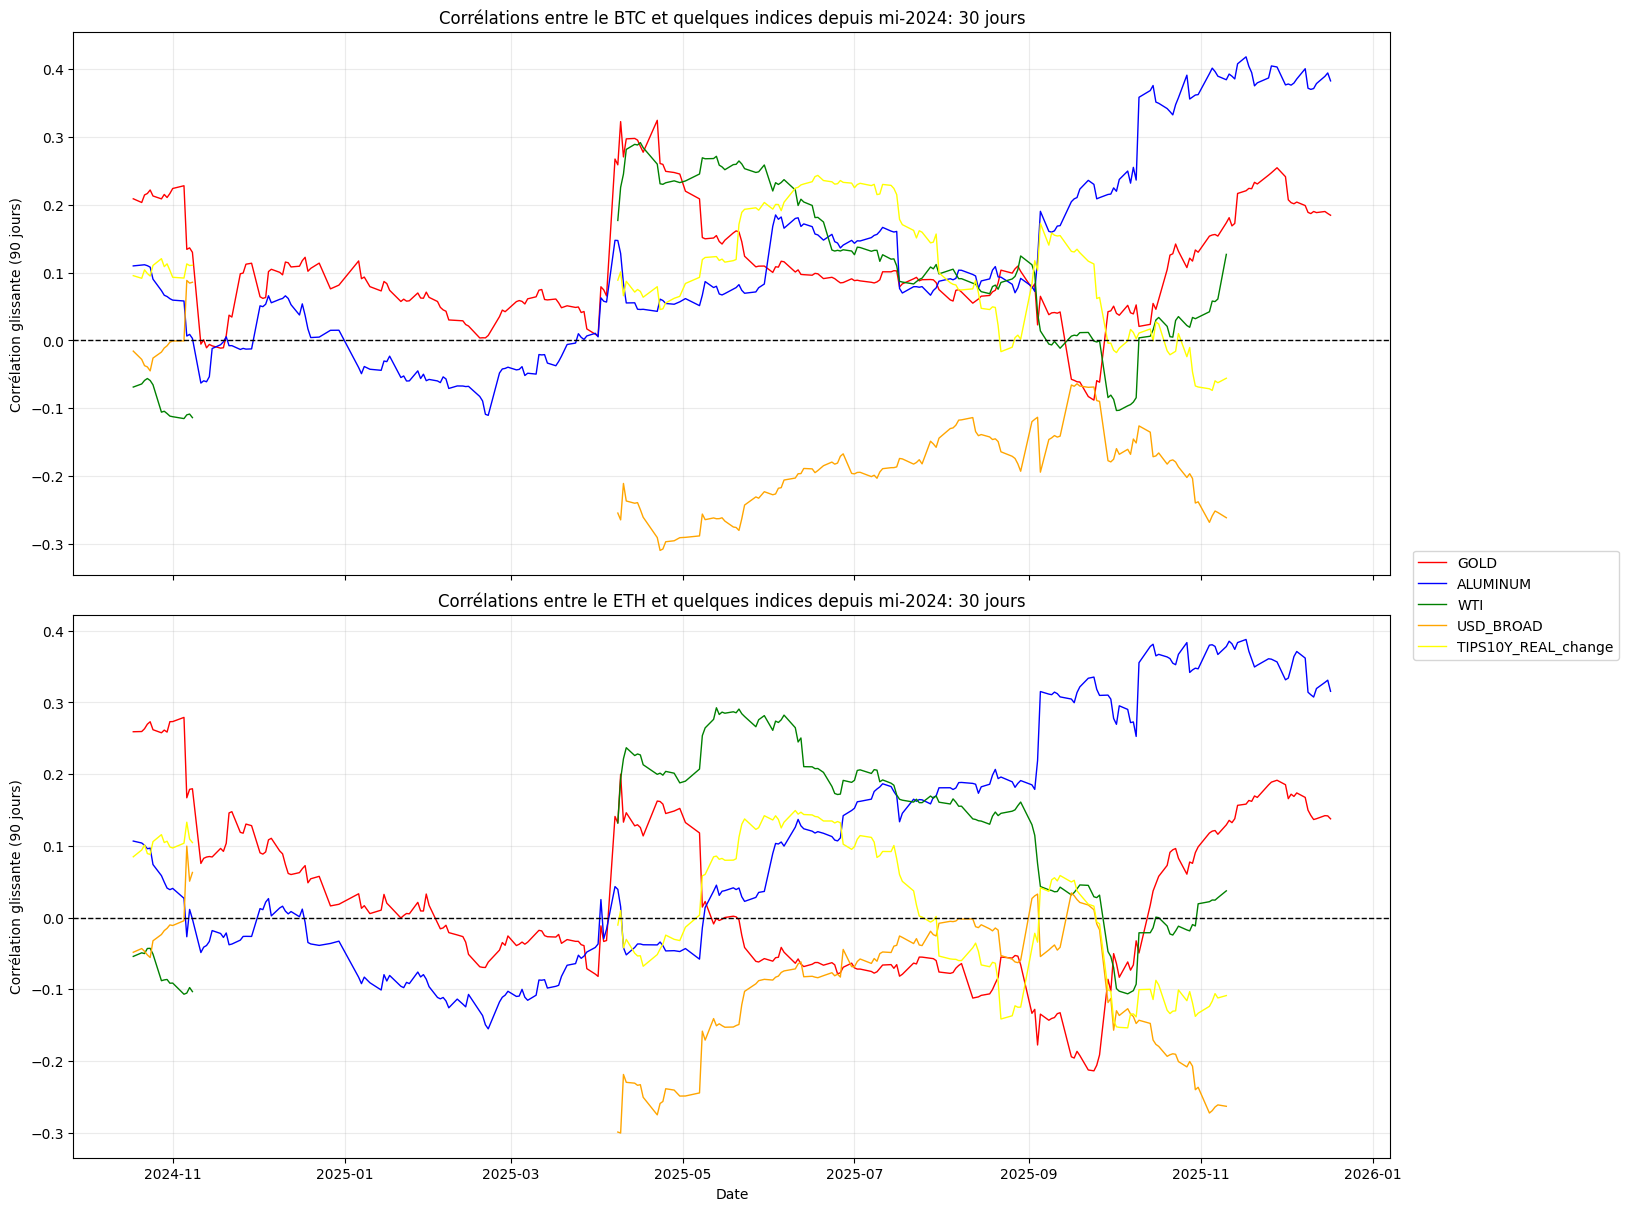

In [23]:
df_recent = (df.loc[df['timestamp'] >= start_date, ['timestamp', 'BTC_return_daily', 'ETH_return_daily',
             'GOLD_return_daily', 'ALUMINUM_return_daily', 'WTI_return_daily', 'USD_BROAD_return_daily', 
             'TIPS10Y_REAL_change']].copy().reset_index(drop=True))

indices = ['GOLD_return_daily', 'ALUMINUM_return_daily', 'WTI_return_daily', 'USD_BROAD_return_daily', 'TIPS10Y_REAL_change']

btc_2024_rolling_corr = pd.DataFrame({'timestamp': df_recent['timestamp']})
eth_2024_rolling_corr = pd.DataFrame({'timestamp': df_recent['timestamp']})

for col in indices:
    btc_2024_rolling_corr[col] = df_recent['BTC_return_daily'].rolling(time).corr(df_recent[col]).to_numpy()
    eth_2024_rolling_corr[col] = df_recent['ETH_return_daily'].rolling(time).corr(df_recent[col]).to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

for col in indices:
    axes[0].plot(btc_2024_rolling_corr['timestamp'], btc_2024_rolling_corr[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))
    axes[1].plot(eth_2024_rolling_corr['timestamp'], eth_2024_rolling_corr[col], color=colors[col], linewidth=1, label=col.replace('_return_daily', ''))

for ax in axes:
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel(f'corr-{time}j')
    ax.grid(True, alpha=0.25)

axes[0].set_title(f'Corrélations entre le BTC et quelques indices depuis mi-2024: {time} jours')
axes[1].set_title(f'Corrélations entre le ETH et quelques indices depuis mi-2024: {time} jours')
axes[1].set_xlabel('Date')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [30]:
vix_q1 = df["VIX"].quantile(0.25) 
vix_q4 = df["VIX"].quantile(0.75)

usd_q1 = df['USD_BROAD'].quantile(0.25)
usd_q4 = df['USD_BROAD'].quantile(0.75)

df_vix_q1 = df[df['VIX'] <= vix_q1]
df_vix_q4 = df[df['VIX'] >= vix_q4]

df_usd_q1 = df[df['USD_BROAD'] <= usd_q1]
df_usd_q4 = df[df['USD_BROAD'] >= usd_q4]

cols = ['BTC_return_daily', 'ETH_return_daily']

def stats(df, cols):
    stat = {}
    for col in cols:
        df_temp = df[col].dropna()
        stat[f"{col}_mean"] = df_temp.mean()
        stat[f"{col}_median"] = df_temp.median()
        stat[f"{col}_std"] = df_temp.std(ddof=1)
        stat[f"{col}_min"] = df_temp.min()
        stat[f"{col}_max"] = df_temp.max()
    return pd.Series(stat)

summary = pd.DataFrame({"VIX_Q1": stats(df_vix_q1, cols), "VIX_Q4": stats(df_vix_q4, cols), 
                        "USD_Q1": stats(df_usd_q1, cols), "USD_Q4": stats(df_usd_q4, cols),}).T

summary

,BTC_return_daily_mean,BTC_return_daily_median,BTC_return_daily_std,BTC_return_daily_min,BTC_return_daily_max,ETH_return_daily_mean,ETH_return_daily_median,ETH_return_daily_std,ETH_return_daily_min,ETH_return_daily_max
VIX_Q1,0.002061,0.001962,0.045007,-0.220518,0.225119,0.002380,0.000213,0.055214,-0.327150,0.264447
VIX_Q4,0.000394,0.001238,0.054247,-0.464730,0.181200,-0.000416,0.000101,0.072616,-0.550732,0.324971
USD_Q1,0.002950,0.003315,0.054956,-0.238740,0.225119,0.004950,0.002025,0.072302,-0.317459,0.324971
USD_Q4,0.001721,-0.000512,0.036005,-0.154890,0.167104,0.000168,-0.000166,0.049451,-0.211327,0.224158


In [31]:
delta_vix = summary.loc["VIX_Q4"] - summary.loc["VIX_Q1"]
delta_usd = summary.loc["USD_Q4"] - summary.loc["USD_Q1"]

delta_table = pd.DataFrame({"VIX (Q4 - Q1)": summary.loc["VIX_Q4"] - summary.loc["VIX_Q1"], 
                            "USD_BROAD (Q4 - Q1)": summary.loc["USD_Q4"] - summary.loc["USD_Q1"],}).T

delta_table

,BTC_return_daily_mean,BTC_return_daily_median,BTC_return_daily_std,BTC_return_daily_min,BTC_return_daily_max,ETH_return_daily_mean,ETH_return_daily_median,ETH_return_daily_std,ETH_return_daily_min,ETH_return_daily_max
VIX (Q4 - Q1),-0.001667,-0.000724,0.009240,-0.244212,-0.043919,-0.002796,-0.000112,0.017402,-0.223581,0.060524
USD_BROAD (Q4 - Q1),-0.001228,-0.003827,-0.018952,0.083851,-0.058015,-0.004782,-0.002191,-0.022851,0.106132,-0.100813


In [33]:
cols = ["BTC_return_daily", "ETH_return_daily"]
max_lag = 10

all_cols = [col for col in df.columns if (col.endswith("_return_daily") or col.endswith("_change")) and col not in cols]

def corr_with_lag(sx, sy, lag):
    tmp = pd.DataFrame({"x": sx, "y": sy.shift(lag)}).dropna()
    n = len(tmp)
    if n < 3:
        return np.nan, n
    return tmp["x"].corr(tmp["y"]), n

rows = []
for x in cols :
    sx = df[x]
    for y in all_cols:
        sy = df[y]

        lag_corrs = []
        for lag in range(-max_lag, max_lag + 1):
            c, n = corr_with_lag(sx, sy, lag)
            lag_corrs.append((lag, c, n))

        lag_df = pd.DataFrame(lag_corrs, columns=["lag", "corr", "n"])
        lag0 = lag_df.loc[lag_df["lag"] == 0, "corr"].iloc[0]

        lag_df["abs_corr"] = lag_df["corr"].abs()
        best_idx = lag_df["abs_corr"].idxmax()
        best = lag_df.loc[best_idx]

        rows.append({
            "target": x,
            "series": y,
            "corr_lag0": lag0,
            "best_lag": int(best["lag"]),
            "best_corr": best["corr"],
            "abs_best_corr": best["abs_corr"],
            "n_at_best": int(best["n"]),
        })

results = pd.DataFrame(rows)

top20_btc = results[results["target"] == "BTC_return_daily"].sort_values("abs_best_corr", ascending=False).head(20)
top20_eth = results[results["target"] == "ETH_return_daily"].sort_values("abs_best_corr", ascending=False).head(20)

top20_btc, top20_eth

(              target                  series  corr_lag0  best_lag  best_corr  \
 1   BTC_return_daily     NASDAQ_return_daily   0.295364         0   0.295364   
 0   BTC_return_daily      SP500_return_daily   0.280047         0   0.280047   
 13  BTC_return_daily        VIX_return_daily  -0.240018         0  -0.240018   
 3   BTC_return_daily       EURO_return_daily   0.214643         0   0.214643   
 2   BTC_return_daily       FTSE_return_daily   0.179251         0   0.179251   
 14  BTC_return_daily  USD_BROAD_return_daily  -0.161772         0  -0.161772   
 4   BTC_return_daily     NIKKEI_return_daily   0.055806        -1   0.147545   
 6   BTC_return_daily     SILVER_return_daily   0.127917         0   0.127917   
 7   BTC_return_daily   ALUMINUM_return_daily   0.110944         0   0.110944   
 5   BTC_return_daily       GOLD_return_daily   0.108371         0   0.108371   
 9   BTC_return_daily        WTI_return_daily   0.097928         0   0.097928   
 8   BTC_return_daily     CO